In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [18]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 =3/2, 5/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [19]:
n_dif=2
ldif=2
jdif=2
def get_system_pair_list_r(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, rs: np.ndarray, erange, theta, b, e
) -> list[pi.SystemPair]:


    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif))



    system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True)


    pi.diagonalize([system1, system2])

    pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
    min_energy, max_energy = pair_energy - erange, pair_energy + erange

    pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )

    pair_systems = []
    for i, r in enumerate(rs):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
            
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="lapacke_evd",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies

In [20]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   asymmetry 4um  energy 4um  asymmetry 3um  energy 3um  energy_Rb 3um  \
0    -583.190951  -34.489343     -28.409727  -93.572437     -11.269094   
1    -472.400891  -34.617153     -47.273165  -94.268968      -4.130529   
2     -89.981441 

In [21]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))


bfield = 0  # Gauss
erange = abs(defect*1000)
e=0
bs = np.array([0])
bs = np.append(bs, np.array(btunes))

Magnetic file doesn't exist


In [22]:
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)
rs = np.linspace(2, 40, 500)
rs = np.append(rs, [5000])
e=0
bs = np.array([2])
# bs = np.append(bs, np.array(btunes))
theta = 0
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}
energies_inter_dict = {}
energies_intra_Rb_dict = {}
energies_intra_Cs_dict = {}
for b in bs:
    while True:
        try:
            pairs = get_system_pair_list_r(ket1, ket2, rs, erange, theta, b, e)
            system_pairs = pairs[0]
            states_num = pairs[1]
            energies = pairs[2]

            
            system_pairs_dict_inter.update({f'{theta}{b}': system_pairs})
            energies_inter_dict.update({f'{theta}{b}' : energies})

            break
        except RuntimeError: # Replace Exception with something more specific.
            continue


In [8]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')
if not os.path.exists(datapath + 'intra Rb'):
    os.makedirs(datapath + 'intra Rb')
if not os.path.exists(datapath + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')


energies_inter_dict.update({'rs' : rs})

energies_intra_Rb_dict.update({'rs' : rs})

energies_intra_Cs_dict.update({'rs' : rs})
print(states_num, states_num_Rb, states_num_Cs)
    

730 726 748


In [8]:
print(bs)

[0]


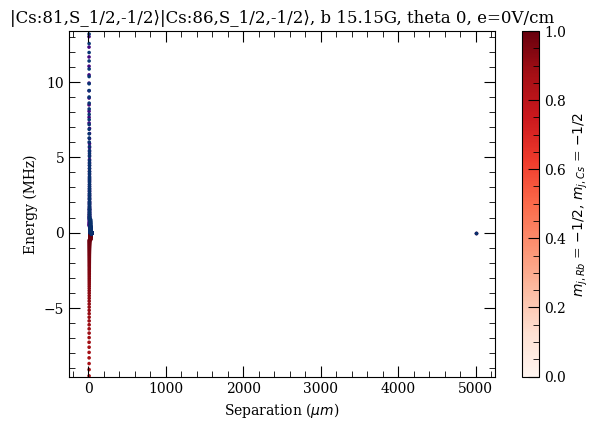

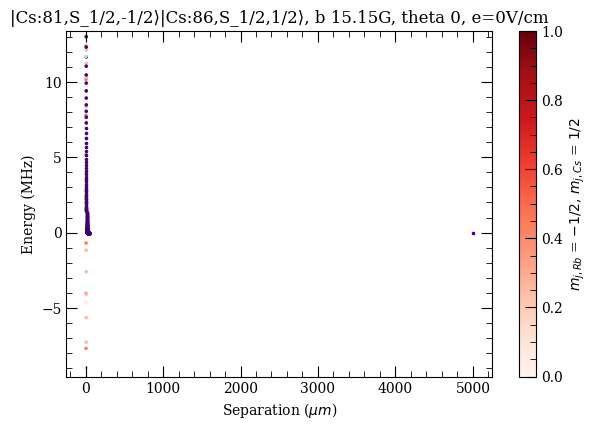

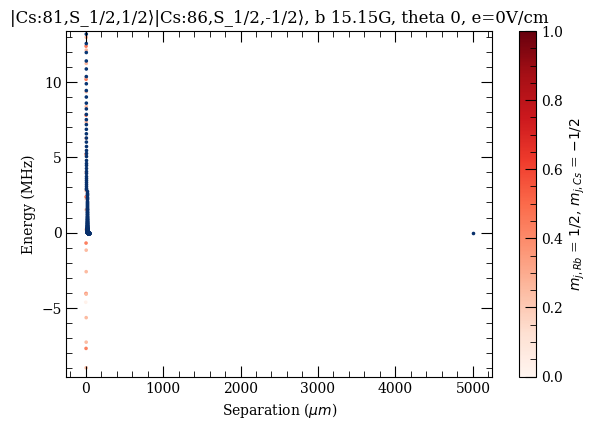

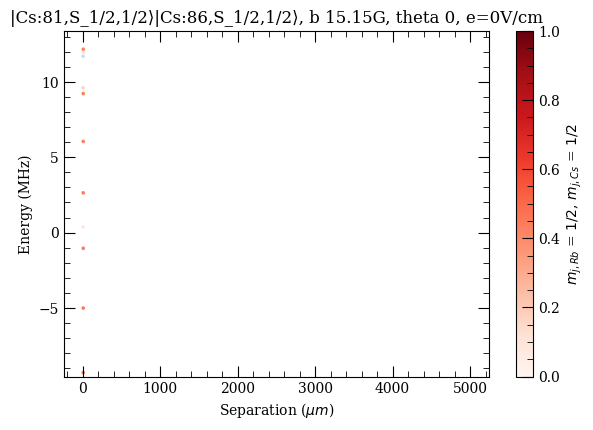

In [9]:
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            import os

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{theta}{b}']
            system_pairs_Rb = system_pairs_dict_Rb[f'{theta}{b}']
            system_pairs_Cs = system_pairs_dict_Cs[f'{theta}{b}']

            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
            overlaps_intra_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in system_pairs_Rb]
            overlaps_intra_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in system_pairs_Cs]

            energies_inter = energies_inter_dict[f'{theta}{b}']
            energies_intra_Rb = energies_intra_Rb_dict[f'{theta}{b}']
            energies_intra_Cs = energies_intra_Cs_dict[f'{theta}{b}']
            rs = energies_inter_dict['rs']
            rs_Rb = energies_intra_Rb_dict['rs']
            rs_Cs = energies_intra_Cs_dict['rs']

            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, b {np.round(b,3)}G, theta {theta}, e={0}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            plt.ylabel(f"Energy ({energy_unit})")
            plt.xlabel(fr"Separation ($\mu m$)")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            r, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, es, os in zip(rs, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")

            r, energy, overlap = [], [], []
            for x, es, os in zip(rs_Rb, energies_intra_Rb, overlaps_intra_Rb):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[1])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Purples'
                    )
            overlapped_intra_Rb = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            
            r, energy, overlap = [], [], []
            for x, es, os in zip(rs_Cs, energies_intra_Cs, overlaps_intra_Cs):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[2])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Blues'
                    )
            plt.show()
            overlapped_intra_Cs = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            pd.DataFrame(overlapped_intra_Rb).to_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {np.round(b,3)}G.csv')
            pd.DataFrame(overlapped_intra_Cs).to_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            # fig.savefig(figpath + f'b {b}G theta{theta} e{e}Vcm mjs{mj1},{mj2}.png')
            plt.close()


|Cs:81,S_1/2,1/2⟩ |Cs:86,S_1/2,1/2⟩


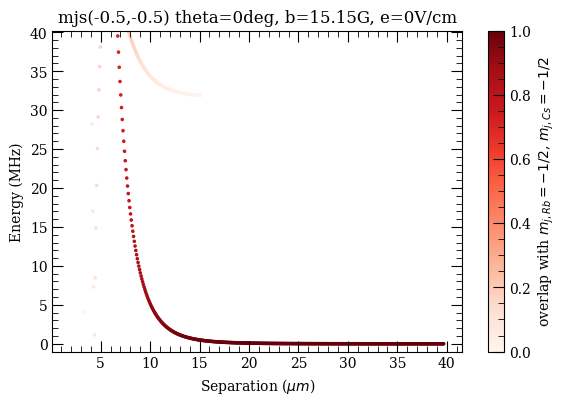

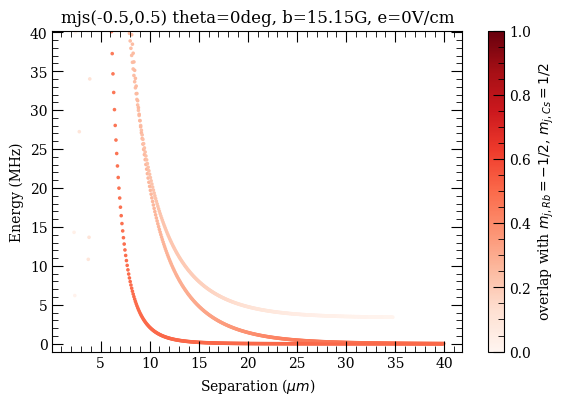

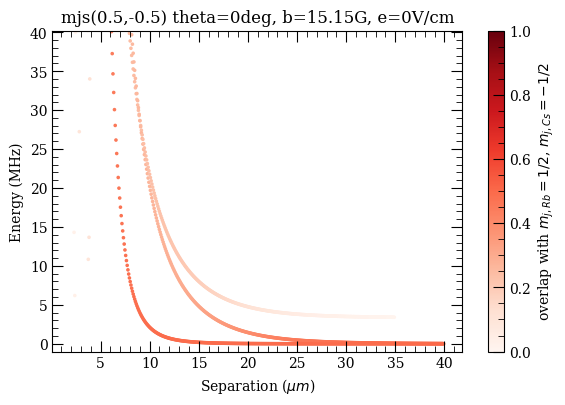

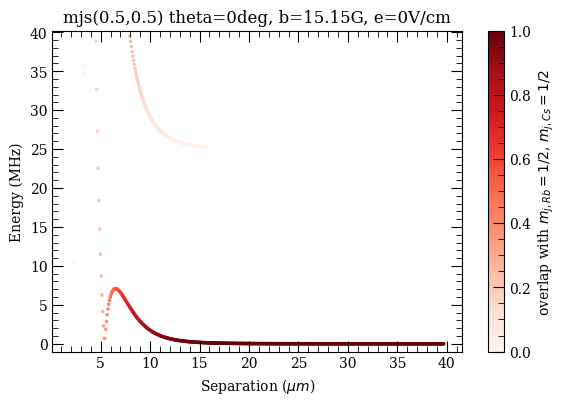

In [11]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
theta=0
# system_atom = system_atom_dict[efield]
b=0

print(ket1, ket2)
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')


            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            
            ax.set_ylabel(f"Energy ({energy_unit})")
            ax.set_xlabel(fr"Separation ($\mu m$)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) theta={theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect*10)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(-1, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            energy = [e - overlapped_inter['energy'].iloc[-1] for e in overlapped_inter['energy'][:-5]]
            energies['energy'] = energy
            energies['r'] = overlapped_inter['r'][:-5]
            energies['overlap'] = overlapped_inter['overlap'][:-5]
            scat = plt.scatter(
                energies['r'],
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )
            plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            # pd.DataFrame(energies_Rb).to_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {np.round(b,3)}G.csv')
            # pd.DataFrame(energies_Cs).to_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()

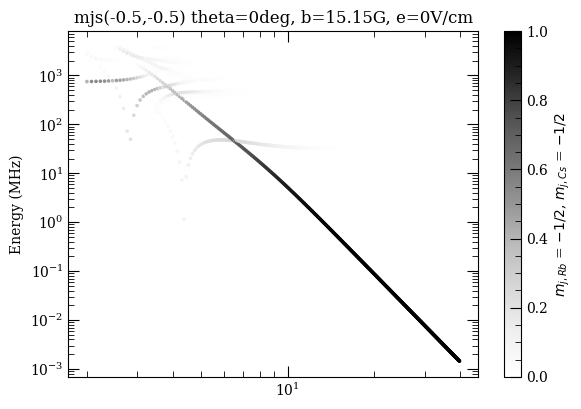

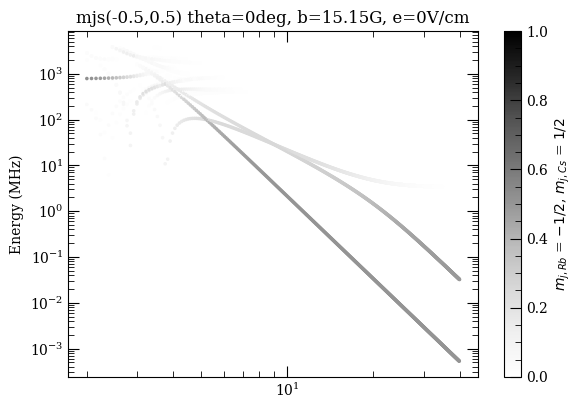

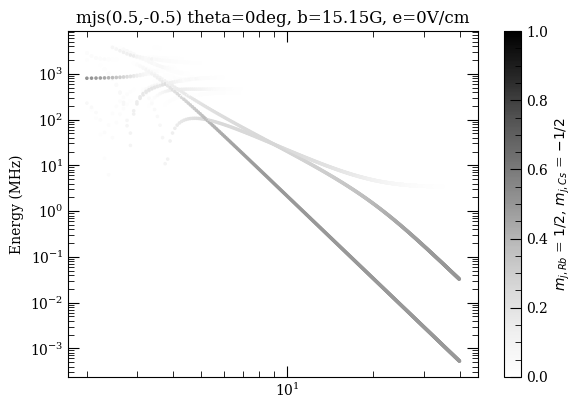

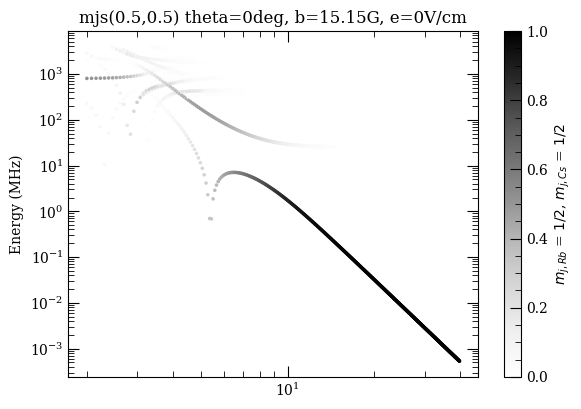

In [ ]:
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'

import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# thetas = [0, 45, 90]
# system_atom = system_atom_dict[efield]
bs=[2]
theta=0
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta+45}, b {b}G.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta+45}, b {b}G.csv')

            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            
            ax.set_ylabel(f"Energy ({energy_unit})")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) theta={theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect*10)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(-1, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            energy = [e - overlapped_inter['energy'].iloc[-1] for e in overlapped_inter['energy'][:-5]]
            energies['energy'] = energy
            energies['r'] = overlapped_inter['r'][:-5]
            energies['overlap'] = overlapped_inter['overlap'][:-5]
            scat = plt.scatter(
                energies['r'],
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greys'
            )
            plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")
            # print(overlapped_intra_Rb['r'][:-5])
            energies_Rb = {'energy' : [], 'r' : [], 'overlap' : []}
            energy_Rb = [e - overlapped_intra_Rb['energy'].iloc[-1] for e in overlapped_intra_Rb['energy'][:-5]]
            energies_Rb['energy'] = energy_Rb
            energies_Rb['r'] = overlapped_intra_Rb['r'][:-5]
            energies_Rb['overlap'] = overlapped_intra_Rb['overlap'][:-5]

            scat = plt.scatter(
                energies_Rb['r'],
                abs(np.array(energies_Rb['energy'])),
                c=energies_Rb['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )

            energies_Cs = {'energy' : [], 'r' : [], 'overlap' : []}
            energy_Cs = [e - overlapped_intra_Cs['energy'].iloc[-1] for e in overlapped_intra_Cs['energy'][:-5]]
            energies_Cs['energy'] = energy_Cs
            energies_Cs['r'] = overlapped_intra_Cs['r'][:-5]
            energies_Cs['overlap'] = overlapped_intra_Cs['overlap'][:-5]
                    

            scat = plt.scatter(
                energies_Cs['r'],
                abs(np.array(energies_Cs['energy'])),
                c=energies_Cs['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )
            ax.set_yscale('log')
            ax.set_xscale('log')
            # print(np.array(energies_Cs['energy']))
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            pd.DataFrame(energies_Rb).to_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            pd.DataFrame(energies_Cs).to_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')
            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()

|Rb:68,S_1/2,1/2⟩ |Cs:67,S_1/2,1/2⟩


C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


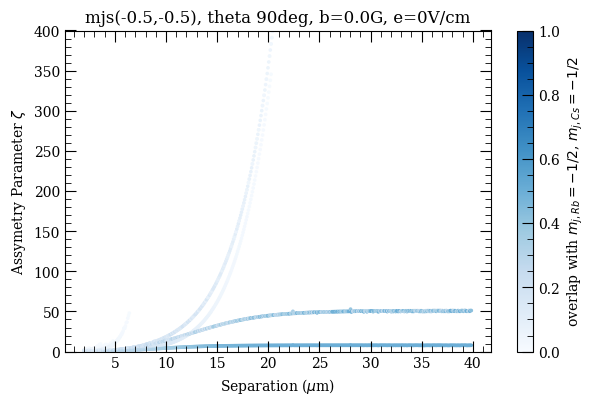

[np.float64(-0.4850508249489445), np.float64(1.0531950534783208), np.float64(-1.5428118464548382), np.float64(-1.5523137906337483), np.float64(1.8383828059498066), np.float64(1.8434152719323746), np.float64(0.3634437709902341), np.float64(0.3680945872164006), np.float64(-1.1096411428158208), np.float64(-1.1101214594395552), np.float64(1.0531950534783208), np.float64(1.060661711629646), np.float64(-1.159880232993156), np.float64(-1.5439897417468806), np.float64(-1.07985880648706), np.float64(1.8467970218202296), np.float64(-1.5439897417468806), np.float64(-1.1643387992092797), np.float64(1.8527896527817072), np.float64(-1.1341814517835753), np.float64(-1.557748171045276), np.float64(1.032396577455909), np.float64(-1.159880232993156), np.float64(0.35235713727303203), np.float64(0.3570186999491001), np.float64(1.032396577455909), np.float64(1.0415492140000764), np.float64(-1.5404220739854755), np.float64(1.0190991716303528), np.float64(-1.246517679125502), np.float64(-2.815339717438655), 

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


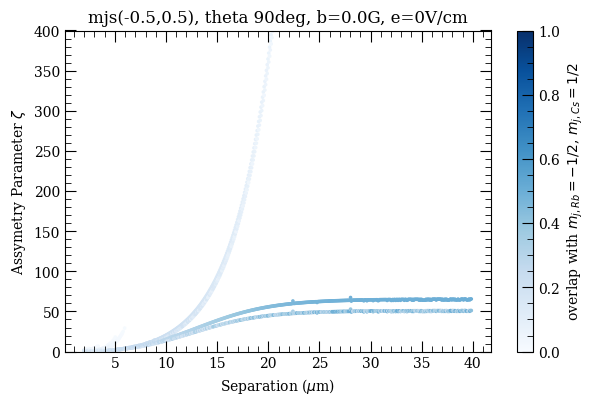

[np.float64(1.0531950534783208), np.float64(-1.5428118464548382), np.float64(-1.5395683629254848), np.float64(1.8383828059498066), np.float64(1.8366902397807976), np.float64(0.3634437709902341), np.float64(0.36173131752907595), np.float64(-1.1096411428158208), np.float64(-1.107496923926833), np.float64(1.0531950534783208), np.float64(1.0506548531019155), np.float64(-1.159880232993156), np.float64(-1.064109599981352), np.float64(-1.5439897417468806), np.float64(-1.07985880648706), np.float64(1.8467970218202296), np.float64(-1.5439897417468806), np.float64(1.844778366271427), np.float64(1.032396577455909), np.float64(-1.5404939586006845), np.float64(-1.159880232993156), np.float64(0.35235713727303203), np.float64(-1.1559703464094244), np.float64(0.3505960802669827), np.float64(1.032396577455909), np.float64(1.0292673751446044), np.float64(1.0190991716303528), np.float64(-1.246517679125502), np.float64(-2.802047950974297), np.float64(-2.7974570093772373), np.float64(-1.235064182393616), n

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


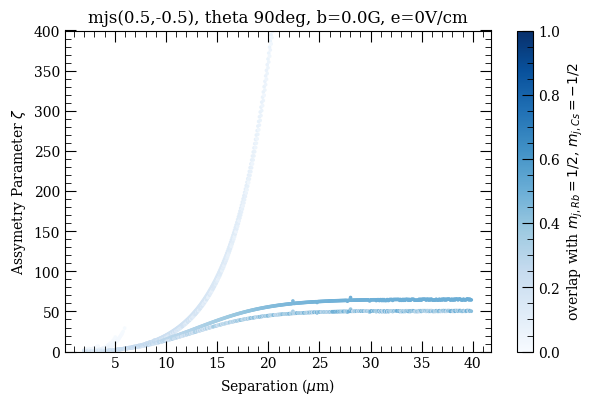

[np.float64(1.0531950534783208), np.float64(-1.5428118464548382), np.float64(-1.5395683629254848), np.float64(1.8383828059498066), np.float64(1.8366902397807976), np.float64(0.3634437709902341), np.float64(0.36173131752907595), np.float64(-1.1096411428158208), np.float64(-1.107496923926833), np.float64(1.0531950534783208), np.float64(1.0506548531019155), np.float64(-1.159880232993156), np.float64(-1.064109599981352), np.float64(-1.5439897417468806), np.float64(-1.07985880648706), np.float64(1.8467970218202296), np.float64(-1.5439897417468806), np.float64(1.844778366271427), np.float64(1.032396577455909), np.float64(-1.5404939586006845), np.float64(-1.159880232993156), np.float64(0.35235713727303203), np.float64(-1.1559703464094244), np.float64(0.3505960802669827), np.float64(1.032396577455909), np.float64(1.0292673751446044), np.float64(1.0190991716303528), np.float64(-1.246517679125502), np.float64(-2.802047950974297), np.float64(-2.7974570093772373), np.float64(-1.235064182393616), n

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


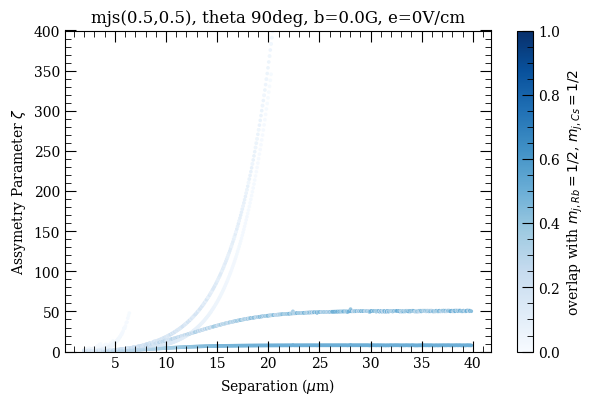

[np.float64(-0.4850508249489445), np.float64(1.0531950534783208), np.float64(-1.5428118464548382), np.float64(-1.5523137906337483), np.float64(1.8383828059498066), np.float64(1.8434152719323746), np.float64(0.3634437709902341), np.float64(0.3680945872164006), np.float64(-1.1096411428158208), np.float64(-1.1101214594395552), np.float64(1.0531950534783208), np.float64(1.060661711629646), np.float64(-1.159880232993156), np.float64(-1.5439897417468806), np.float64(-1.07985880648706), np.float64(1.8467970218202296), np.float64(-1.5439897417468806), np.float64(-1.1643387992092797), np.float64(1.8527896527817072), np.float64(-1.1341814517835753), np.float64(-1.557748171045276), np.float64(1.032396577455909), np.float64(-1.159880232993156), np.float64(0.35235713727303203), np.float64(0.3570186999491001), np.float64(1.032396577455909), np.float64(1.0415492140000764), np.float64(-1.5404220739854755), np.float64(1.0190991716303528), np.float64(-1.246517679125502), np.float64(-2.815339717438655), 

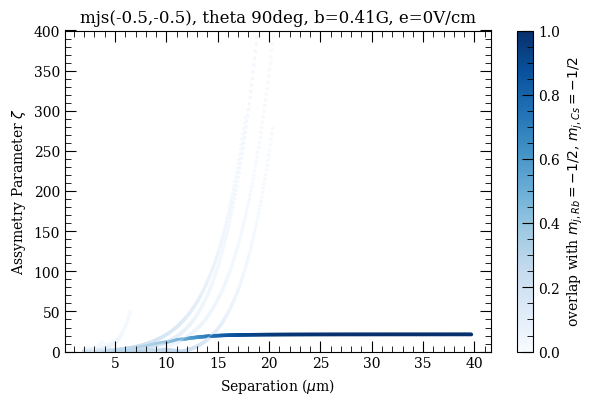

[np.float64(-0.4843386770435911), np.float64(-1.1084123414365452), np.float64(1.8432933937352458), np.float64(-1.5416489918394285), np.float64(-1.5511958248650906), np.float64(0.36855813090741457), np.float64(1.8381371706806438), np.float64(0.36376590293209554), np.float64(1.0608279361369637), np.float64(-1.1094122328851055), np.float64(1.0532741770789478), np.float64(-1.0795009126601278), np.float64(1.8538568208632773), np.float64(-1.1640428951798616), np.float64(-1.133831814477292), np.float64(-1.543713822963165), np.float64(1.8477315114280835), np.float64(-1.5575148519228565), np.float64(-1.1595812732390687), np.float64(0.3577794093670183), np.float64(0.352942291952868), np.float64(1.0424189175405145), np.float64(1.033172002893891), np.float64(-1.542342298171034), np.float64(-1.247947239902246), np.float64(-2.8060638972172764), np.float64(-2.8194289419538463), np.float64(1.8803867672555763), np.float64(-1.5903417840273326), np.float64(1.8731604145472496), np.float64(-1.1699056811288

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


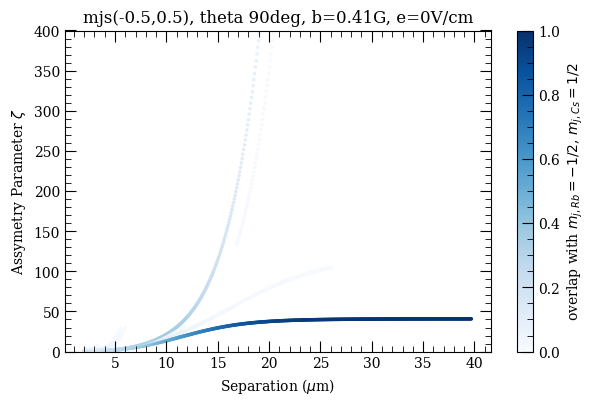

[np.float64(-1.5379739857095025), np.float64(-1.5412144694326642), np.float64(1.834788323107624), np.float64(1.8364792962321834), np.float64(0.3613567372070172), np.float64(0.3630677780270692), np.float64(-1.1084925510338746), np.float64(-1.1063500044563486), np.float64(1.0495669104417111), np.float64(1.0521046622119066), np.float64(-1.0641233352592483), np.float64(-1.0798777135083795), np.float64(1.8448009160382102), np.float64(1.8468197807518691), np.float64(-1.5405126082621055), np.float64(-1.544008935876182), np.float64(-1.1599571617309907), np.float64(0.3506004403425601), np.float64(0.35236181785752385), np.float64(-1.1559815154688091), np.float64(1.0292799938652437), np.float64(1.0324094445370142), np.float64(-1.246750245970601), np.float64(-2.7979585276680474), np.float64(-2.8025511254883715), np.float64(-1.2352773022768306), np.float64(1.8673763868422593), np.float64(1.8697644179995565), np.float64(-1.1586371282836359), np.float64(-1.1688293443542006), np.float64(-1.56040816610

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


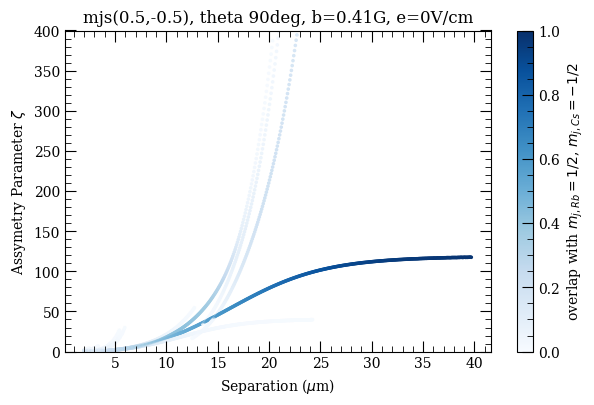

[np.float64(-1.5416072507898355), np.float64(-1.5383659412234054), np.float64(1.8369473263763958), np.float64(1.8352559223042093), np.float64(0.3631603065215954), np.float64(0.3614488296396268), np.float64(-1.1066319598005758), np.float64(-1.1087750524100586), np.float64(1.0523727930303657), np.float64(1.0498343945094393), np.float64(-1.0638006708084593), np.float64(-1.0795502720006114), np.float64(1.8462597863691528), np.float64(1.8442415338174984), np.float64(-1.5435407600747495), np.float64(-1.5400454926203295), np.float64(-1.1596054384597052), np.float64(-1.1556309976966186), np.float64(0.3522549743849011), np.float64(0.3504941309564381), np.float64(1.0320963964011705), np.float64(1.0289678946442942), np.float64(-1.2478022486916724), np.float64(-2.804915906581846), np.float64(-2.800319433546402), np.float64(-1.2363196241752805), np.float64(1.8713421175122338), np.float64(1.8689520713440844), np.float64(-1.1596147815190199), np.float64(-1.169815597739514), np.float64(-1.566886660843

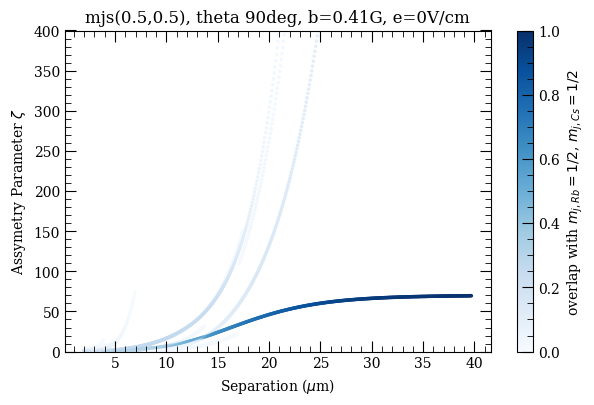

[np.float64(-0.4849075671776845), np.float64(-1.1093342078785775), np.float64(1.8351646517646583), np.float64(-1.550660579277306), np.float64(-1.5411236266741501), np.float64(0.36231927338879305), np.float64(1.8403155384252772), np.float64(0.3671065416840783), np.float64(1.0511139461715164), np.float64(-1.1083353512600957), np.float64(1.058659887523828), np.float64(-1.0799156258553355), np.float64(1.8452171785539024), np.float64(-1.164396968841038), np.float64(-1.5575866994592118), np.float64(1.851338094480701), np.float64(-1.134207557678285), np.float64(0.3515001284203836), np.float64(-1.5437955695809034), np.float64(-1.159938547093421), np.float64(0.35633377630924823), np.float64(1.0312419301419125), np.float64(1.0404822122424484), np.float64(-1.5403483653045182), np.float64(-1.2465863131544712), np.float64(-2.8146890266498836), np.float64(-2.8013527193355556), np.float64(1.8678103582570118), np.float64(-1.5882446430145176), np.float64(1.8750211729141653), np.float64(-1.1687125587746

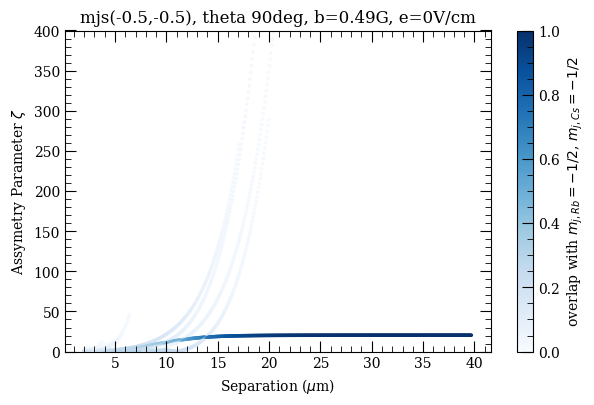

[np.float64(-0.4842258639503354), np.float64(1.843344160697321), np.float64(-1.5414792784879359), np.float64(-1.5510452607634693), np.float64(0.3686707413092641), np.float64(1.838138306077113), np.float64(0.36382214002439006), np.float64(1.0609028084280363), np.float64(-1.109341875864545), np.float64(1.0533133529173453), np.float64(-1.0793665000820518), np.float64(1.8539504295215359), np.float64(-1.1336946816959768), np.float64(-1.1639239009902076), np.float64(-1.5435608201109388), np.float64(1.8477730803925358), np.float64(-1.1594596858083714), np.float64(0.35791544822184385), np.float64(-1.5573774651013133), np.float64(0.3530098137168673), np.float64(1.0425234610867138), np.float64(1.0332398109849212), np.float64(-1.5421143981138705), np.float64(-1.2477403506244107), np.float64(-2.805741594796977), np.float64(-2.8191262220219646), np.float64(1.880409578173201), np.float64(-1.590114005275705), np.float64(1.8731284332940432), np.float64(-1.1697004229217274), np.float64(0.35328751081267

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


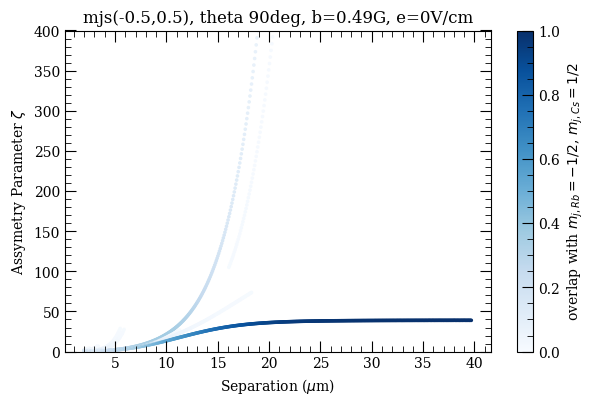

[np.float64(-1.537988452626156), np.float64(-1.5412291116838368), np.float64(1.8348056463712916), np.float64(1.8364966999984254), np.float64(0.3613601505845195), np.float64(0.3630713527388396), np.float64(-1.108503199823147), np.float64(-1.1063604126002862), np.float64(1.0495768297465624), np.float64(1.0521146790609537), np.float64(-1.0641084721751009), np.float64(-1.0798646307790245), np.float64(1.8447746443387052), np.float64(1.8467935549553478), np.float64(-1.159964515979206), np.float64(-1.5404905966734754), np.float64(-1.5439870771263424), np.float64(0.3505954800339183), np.float64(0.352356952596414), np.float64(-1.1559638578660067), np.float64(1.0292653507854357), np.float64(1.0323948419645175), np.float64(-1.2467820653921122), np.float64(-2.7980217102817204), np.float64(-2.802614745292071), np.float64(-1.235301855960982), np.float64(1.867418644486437), np.float64(1.8698068154539524), np.float64(-1.1586657037245596), np.float64(-1.1688572874289263), np.float64(-1.5604432102697257

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


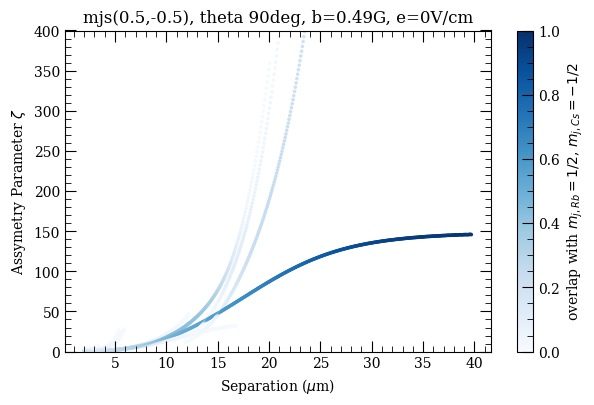

[np.float64(-1.5415926548762855), np.float64(-1.538351231416005), np.float64(1.836929890539778), np.float64(1.8352384380290327), np.float64(0.3631569935547707), np.float64(0.36144538776422974), np.float64(-1.1066213795086755), np.float64(-1.1087646721695024), np.float64(1.0523628505536593), np.float64(1.0498244026145502), np.float64(-1.0638160322985881), np.float64(-1.0795678607715178), np.float64(1.8462860163976933), np.float64(1.844267660621076), np.float64(-1.5435627562962968), np.float64(-1.5400672367513997), np.float64(-1.1596457328018492), np.float64(-1.1556461741554764), np.float64(0.35226011733346835), np.float64(0.35049912886148804), np.float64(1.0321111176751323), np.float64(1.0289824865474815), np.float64(-1.2477773386778934), np.float64(-2.8048519988295997), np.float64(-2.8002552973203687), np.float64(-1.2362879648979335), np.float64(1.8712994329888442), np.float64(1.8689093556073435), np.float64(-1.1595906360395791), np.float64(-1.169790355416797), np.float64(-1.5668513135

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


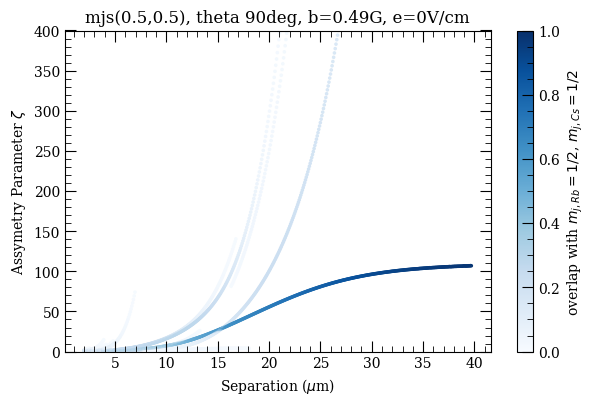

[np.float64(-0.48503076659655187), np.float64(1.8351135921900938), np.float64(-1.5508304535297646), np.float64(0.36220663819814014), np.float64(-1.5412736148137376), np.float64(1.8403144708402315), np.float64(0.3670506049903824), np.float64(1.051038807016713), np.float64(-1.1084058568529083), np.float64(1.058621008213515), np.float64(-1.0800500090886798), np.float64(1.8451234026056853), np.float64(-1.1645506125270768), np.float64(-1.5577398926527575), np.float64(-1.1343416982936716), np.float64(1.8512966023900201), np.float64(0.35136417307548284), np.float64(-1.5439325283458902), np.float64(-1.1600893959724934), np.float64(0.35626651245047136), np.float64(1.0311372577340663), np.float64(1.040414671979148), np.float64(-1.5405729936279908), np.float64(-1.246792235032671), np.float64(-2.815011095636102), np.float64(-2.801653444127053), np.float64(1.867786671074344), np.float64(-1.5884758611686016), np.float64(1.8750531413501181), np.float64(0.3459922237606766), np.float64(-1.1689095909723

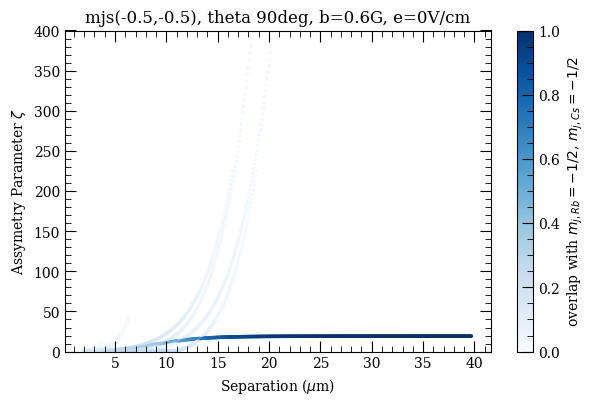

[np.float64(-0.4840726171250891), np.float64(1.8434435277695531), np.float64(-1.5412527445541957), np.float64(0.3688422219405294), np.float64(-1.5508516009546613), np.float64(1.838153762377046), np.float64(0.3638986075782786), np.float64(1.0610260050945084), np.float64(-1.1092577688821577), np.float64(1.0533757214880712), np.float64(-1.1589454201635225), np.float64(-1.0791840491337255), np.float64(1.8541048272442122), np.float64(-1.1592981262385667), np.float64(-1.5433532839584816), np.float64(-1.1335083664664023), np.float64(0.3581202820963621), np.float64(-1.163768809855289), np.float64(1.8478393938435835), np.float64(-1.5571967895917194), np.float64(0.35309957595307634), np.float64(1.0426852107419105), np.float64(1.0333389372010993), np.float64(-1.5418111779940438), np.float64(-1.247463330038109), np.float64(-2.805318739838938), np.float64(1.88047477380968), np.float64(-2.8187372349576623), np.float64(-1.5898125955096767), np.float64(-1.1694236107714344), np.float64(1.87310064854682

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


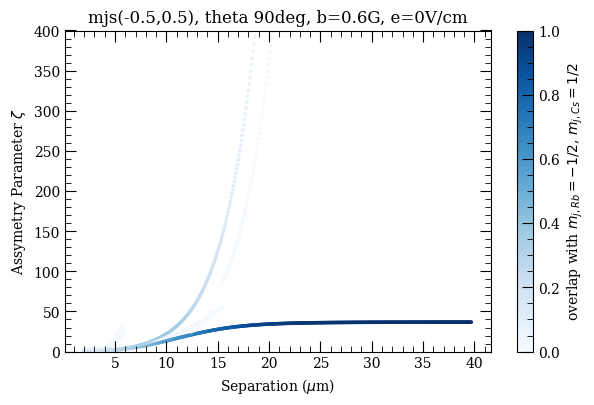

[np.float64(-1.5380023703203742), np.float64(-1.5412433062359543), np.float64(1.834822360613794), np.float64(1.83651353985532), np.float64(0.3613634421415163), np.float64(0.3630749083230718), np.float64(-1.1085136115118266), np.float64(-1.1063704271466974), np.float64(1.0495864075086745), np.float64(1.0521244054863363), np.float64(-1.1595824628247557), np.float64(-1.0640875108397463), np.float64(-1.079846782283952), np.float64(1.8447374361028297), np.float64(1.8467564333598423), np.float64(-1.1599799430428612), np.float64(-1.5404594005311236), np.float64(-1.5439561566272348), np.float64(0.3505884614377779), np.float64(0.35235010452884713), np.float64(-1.1559384915470317), np.float64(1.0292446165954885), np.float64(1.0323741897895697), np.float64(-1.246822581961281), np.float64(-2.798098582855395), np.float64(-2.8026923178566783), np.float64(-1.2353300835092318), np.float64(1.867470111622874), np.float64(1.8698584948631543), np.float64(-1.158701676904982), np.float64(-1.1688920675548253

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


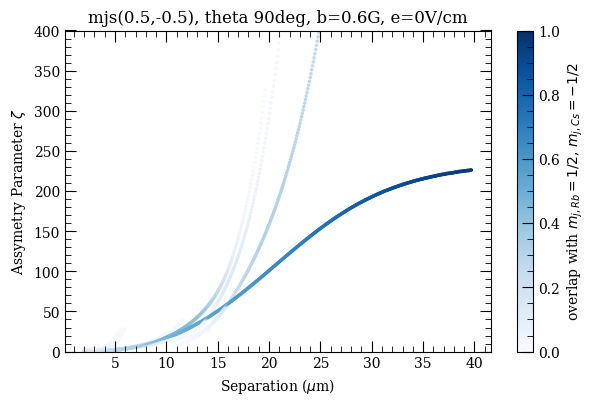

[np.float64(-1.541578591405456), np.float64(1.836913058705466), np.float64(-1.5383369504501567), np.float64(1.8352215115614054), np.float64(0.36315389236906015), np.float64(0.36144205387170836), np.float64(-1.1066111091952076), np.float64(-1.1087547597929752), np.float64(1.0523532867461627), np.float64(1.049814736647315), np.float64(-1.1593104222677655), np.float64(-1.063837873605297), np.float64(-1.0795934478902933), np.float64(1.8463231803012086), np.float64(1.844304656705325), np.float64(-1.543593941169272), np.float64(-1.5400980054197138), np.float64(-1.1597078092361508), np.float64(-1.1556673058735945), np.float64(0.35226744243126923), np.float64(0.3505062126254842), np.float64(1.0321319925689179), np.float64(1.0290031535794855), np.float64(-1.247748745564281), np.float64(-2.8047742111851766), np.float64(-2.800177063869887), np.float64(-1.236247710265107), np.float64(1.8712474614296553), np.float64(1.868857304052734), np.float64(-1.1595623826183774), np.float64(-1.1697603428848258

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


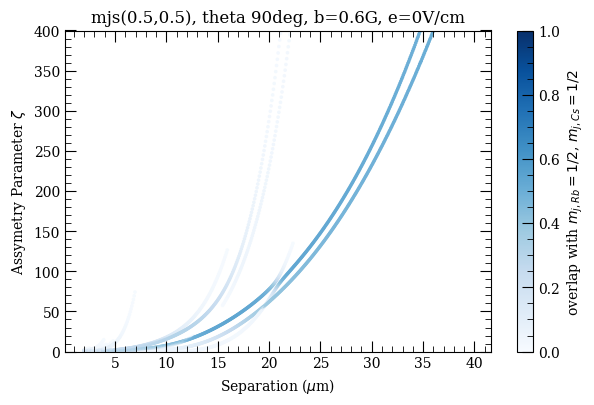

[np.float64(-0.48520182232474096), np.float64(1.8350139180403375), np.float64(-1.551057163397341), np.float64(0.36203520861244787), np.float64(-1.5414666179163101), np.float64(1.8402991034274594), np.float64(0.3669745426751539), np.float64(1.0509153567476854), np.float64(-1.108490298908837), np.float64(1.0585590165556142), np.float64(-1.0802324542346715), np.float64(1.844968838191873), np.float64(-1.1647645586754305), np.float64(-1.5579476189488197), np.float64(0.35115953590381294), np.float64(-1.1345229532236705), np.float64(1.8512303711922677), np.float64(-1.5441127312689074), np.float64(-1.1602966581790943), np.float64(0.35617711652294676), np.float64(1.030975429915957), np.float64(1.0403158851509666), np.float64(-1.54087096580286), np.float64(-1.2470679041845345), np.float64(-2.8154336561755504), np.float64(1.8677204567664596), np.float64(-2.8020399963422298), np.float64(-1.588783541097869), np.float64(1.8750809338143746), np.float64(0.34577840152100797), np.float64(-1.169172622776

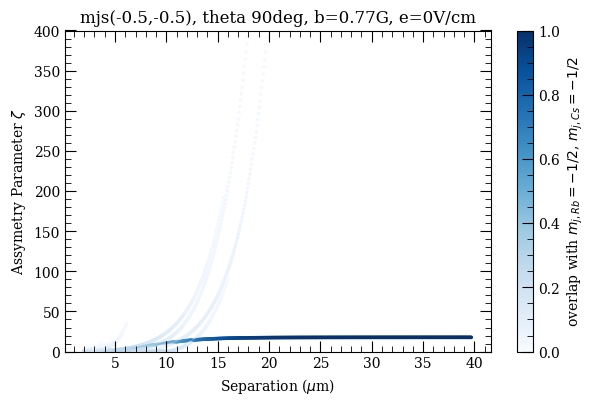

[np.float64(-0.48384724653550076), np.float64(1.8436490116786242), np.float64(-1.5409242057757728), np.float64(0.3691325082953403), np.float64(-1.5505872333294675), np.float64(1.838199058326105), np.float64(0.36400840844700916), np.float64(1.0612498815559266), np.float64(-1.1091534238673044), np.float64(1.0534820123147224), np.float64(-1.158694131166799), np.float64(-1.0789140442881662), np.float64(1.8543843383923597), np.float64(-1.1590643286113682), np.float64(0.3584626518485236), np.float64(-1.5430448630475821), np.float64(-1.1332320541192638), np.float64(-1.163553289854166), np.float64(1.8479503671592552), np.float64(-1.5569409353980586), np.float64(0.3532245792272371), np.float64(1.0429619791139833), np.float64(1.0334945024832407), np.float64(-1.5413791897854894), np.float64(-2.8047279852052682), np.float64(-1.2470651193450342), np.float64(1.8806423754296993), np.float64(-2.8182130840710164), np.float64(-1.5893869546585562), np.float64(0.35386571248268006), np.float64(-1.169021211

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


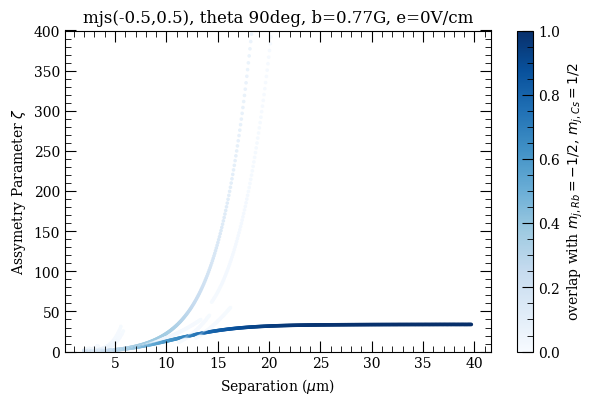

[np.float64(-1.538013295996018), np.float64(1.8348356100534589), np.float64(-1.5412547383749877), np.float64(1.8365270162841998), np.float64(0.3613660530233692), np.float64(0.3630780170644033), np.float64(-1.1085222259583807), np.float64(-1.1063782905258965), np.float64(1.0495940467935585), np.float64(1.0521323076541689), np.float64(-1.0640572562734938), np.float64(-1.1595651244938923), np.float64(-1.0798227577403672), np.float64(1.844683299516226), np.float64(1.8467024859668073), np.float64(-1.1600151327954937), np.float64(-1.5404139523067566), np.float64(-1.543911279677324), np.float64(0.3505782779476046), np.float64(0.35234027174194027), np.float64(-1.1559005429273606), np.float64(1.0292144906480893), np.float64(1.0323442543883987), np.float64(-1.2468765804194692), np.float64(-2.7981924687676614), np.float64(-2.8027874752791675), np.float64(-1.2353603719790727), np.float64(1.8675330582109222), np.float64(1.8699218073516912), np.float64(-1.1587486086954168), np.float64(-1.16893647167

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


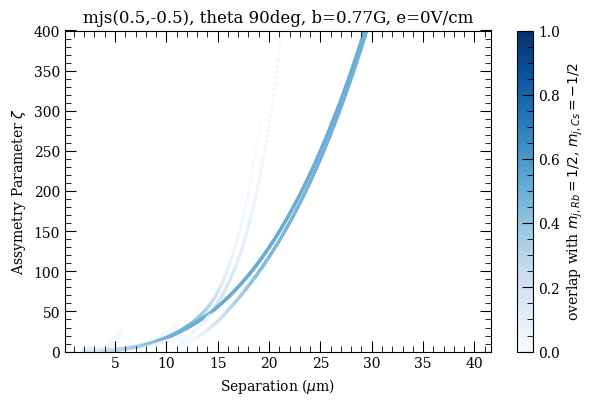

[np.float64(-1.5415673700635246), np.float64(1.836899541686944), np.float64(-1.5383252701828591), np.float64(1.8352077923674373), np.float64(0.3631516646521247), np.float64(0.3614393533523309), np.float64(-1.1066027108663603), np.float64(-1.1087470811796838), np.float64(1.0523457246135568), np.float64(1.0498069488862218), np.float64(-1.0638697757111681), np.float64(-1.1593608160130173), np.float64(-1.079632499390415), np.float64(1.8463771079681368), np.float64(1.844358277286203), np.float64(-1.5436392516889914), np.float64(-1.1598107450258315), np.float64(-1.540142540526714), np.float64(-1.1556968801239702), np.float64(0.3522781914808578), np.float64(0.35051650813935303), np.float64(1.0321623614684594), np.float64(1.0290331491739133), np.float64(-1.247718044193925), np.float64(-2.804678956894094), np.float64(-1.2361940639560838), np.float64(-2.8000808494088565), np.float64(1.8711837377517493), np.float64(1.8687933765461617), np.float64(-1.1595305986639752), np.float64(-1.16972533699531

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


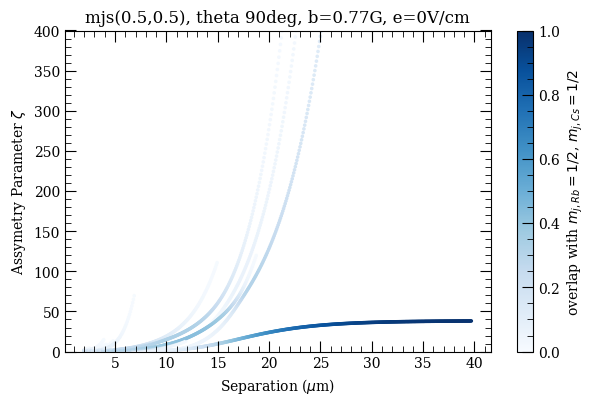

[np.float64(-0.48546185217991783), np.float64(1.834807990952916), np.float64(-1.5513857386415515), np.float64(0.3617451580621983), np.float64(-1.541730103704704), np.float64(1.840253774865087), np.float64(0.36686533776162633), np.float64(1.0506912860274262), np.float64(-1.1085953271458557), np.float64(1.058453212526493), np.float64(-1.1602368999513935), np.float64(-1.1596748536632193), np.float64(-1.0805024146570792), np.float64(1.8446890272628733), np.float64(-1.1650932811871022), np.float64(0.35081761122637317), np.float64(-1.5582560698702177), np.float64(-1.1347893767994333), np.float64(1.8511193208955494), np.float64(-1.1606068857944134), np.float64(-1.5443679403904476), np.float64(0.3560526898121848), np.float64(1.030698698276774), np.float64(1.0401607633825265), np.float64(-1.5412931300339223), np.float64(-1.2474638514729859), np.float64(-2.8160238333217595), np.float64(1.8675515163089083), np.float64(-2.8025609470074357), np.float64(-1.589221816884897), np.float64(0.345414422354

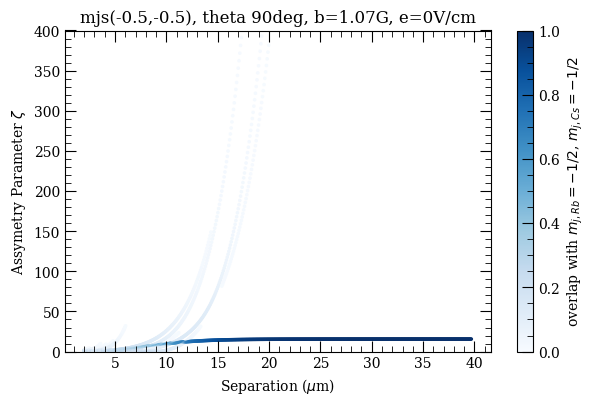

[np.float64(-0.48346903552562387), np.float64(1.844133778770329), np.float64(0.3697167613962042), np.float64(-1.54037021231688), np.float64(-1.550188574813617), np.float64(1.8383114578392947), np.float64(1.06172979725592), np.float64(0.3641769877672969), np.float64(-1.1090150640055223), np.float64(1.0536819773218393), np.float64(-1.0784519061373259), np.float64(1.85497989960593), np.float64(-1.15826146642258), np.float64(-1.1586707213737915), np.float64(0.3591422724595027), np.float64(-1.5425083110900573), np.float64(-1.1327567489763375), np.float64(-1.1632233003557748), np.float64(-1.5565322641112718), np.float64(1.8481522515275057), np.float64(1.0435234552164276), np.float64(0.3534085580061561), np.float64(1.0337664476762705), np.float64(-1.5406871248261542), np.float64(-2.8038062913172457), np.float64(1.8811061698045999), np.float64(-1.2464188519953556), np.float64(-2.817453989502255), np.float64(0.35460448770822506), np.float64(-1.5887163051409046), np.float64(-1.1683551538212298),

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


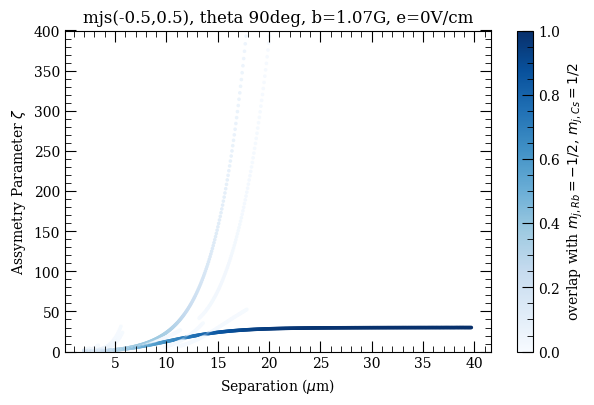

[np.float64(-1.5380145212314595), np.float64(1.8348375973583122), np.float64(-1.5412571431643465), np.float64(1.8365295287385293), np.float64(0.3613664583574836), np.float64(0.36307960606733236), np.float64(-1.1085249079695225), np.float64(-1.106379177460396), np.float64(1.0495952820325665), np.float64(1.0521341425237372), np.float64(-1.0640115933142065), np.float64(-1.0797926782628877), np.float64(-1.1595317203204194), np.float64(-1.1601053384617015), np.float64(1.8446000208388467), np.float64(1.8466197214603217), np.float64(-1.540343815751897), np.float64(-1.5438426286976599), np.float64(0.35056271723472787), np.float64(0.35232561090109815), np.float64(-1.1558384641265682), np.float64(1.0291681688614946), np.float64(1.0322984810606626), np.float64(-1.2469551802868322), np.float64(-2.798302393360956), np.float64(-2.80290030579878), np.float64(-1.2353818481403331), np.float64(1.8676071939558705), np.float64(1.8699967335005667), np.float64(-1.1588137996451144), np.float64(-1.16899506735

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


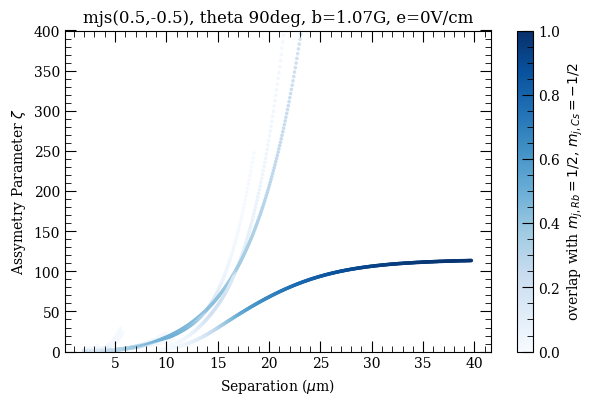

[np.float64(-1.5415657744702205), np.float64(1.8368972872979912), np.float64(-1.5383225032137302), np.float64(1.8352050171144836), np.float64(0.3631523114776227), np.float64(0.3614388207159885), np.float64(-1.106600725987743), np.float64(-1.1087468861718346), np.float64(1.0523448286741968), np.float64(1.049805459785169), np.float64(-1.1587689127381657), np.float64(-1.0639196473082653), np.float64(-1.0796993685427356), np.float64(-1.1594315199926077), np.float64(1.846460146781862), np.float64(1.844440620691761), np.float64(-1.1600050885649777), np.float64(-1.5437092183434848), np.float64(-1.5402107077458145), np.float64(-1.155738582949561), np.float64(0.3522951648675054), np.float64(0.35053242354067027), np.float64(1.0322092755267482), np.float64(1.0290792338318737), np.float64(-2.8045669353102833), np.float64(-1.2476966309544455), np.float64(-1.2361164172014683), np.float64(-2.7999662889127306), np.float64(1.871108650230541), np.float64(1.8687176898443272), np.float64(-1.15950284066196

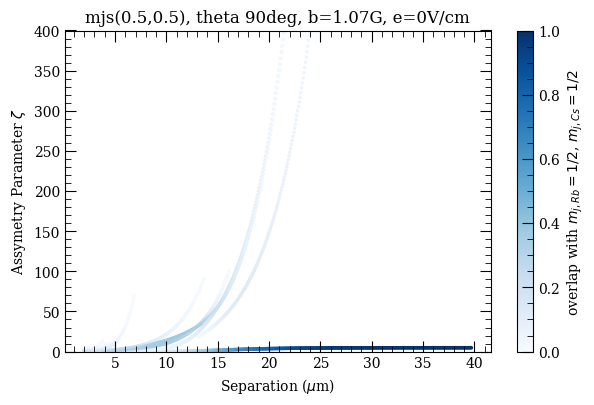

[np.float64(1.8343228871656865), np.float64(0.3611618370989904), np.float64(-1.5519396062486315), np.float64(-1.54212772714311), np.float64(1.8401413634246184), np.float64(1.0502115235830096), np.float64(0.366697952631174), np.float64(-1.1087356427432846), np.float64(1.0582540292739993), np.float64(-1.1607320810673785), np.float64(-1.1599249548231816), np.float64(-1.0809646860885738), np.float64(1.8440932763494926), np.float64(-1.1656912935446024), np.float64(0.35013929180129105), np.float64(-1.55879246273355), np.float64(-1.1352408383755785), np.float64(-1.1611411197993753), np.float64(1.8509173172175455), np.float64(-1.544775918903348), np.float64(1.0301377320669667), np.float64(0.3558699769956597), np.float64(1.039889584745833), np.float64(-2.8169443619224968), np.float64(-1.5419624942154628), np.float64(1.8670862896337954), np.float64(-1.24810562615215), np.float64(0.34467696508518586), np.float64(-2.803315744041472), np.float64(-1.5899245268436148), np.float64(1.8750469273146695),

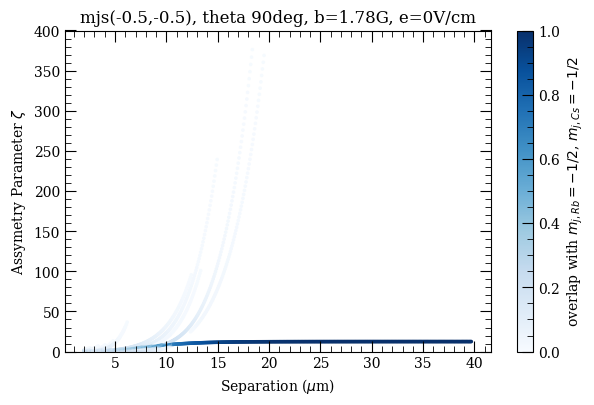

[np.float64(-0.48268382898489715), np.float64(1.8455854765065374), np.float64(0.3712747781636058), np.float64(-1.5391268114010463), np.float64(-1.5494888231338513), np.float64(1.0630866772791883), np.float64(1.838579340599394), np.float64(0.3644392208798586), np.float64(-1.1088057497942385), np.float64(1.0540980364163712), np.float64(1.8566460559211642), np.float64(-1.0774368186476886), np.float64(-1.1577979829815988), np.float64(0.36092647956260204), np.float64(-1.15731888883831), np.float64(-1.5412679263405487), np.float64(-1.1316987191446186), np.float64(-1.162652832378719), np.float64(-1.5557460125968743), np.float64(1.8485526556850993), np.float64(1.0450444820447158), np.float64(0.35367770185341707), np.float64(1.03430473456325), np.float64(1.8826858309137668), np.float64(-1.5393137728672581), np.float64(-2.802020292978701), np.float64(0.35658064891262276), np.float64(-1.2451155827533833), np.float64(-2.8162444244582128), np.float64(-1.1669560910103727), np.float64(-1.587435680046

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


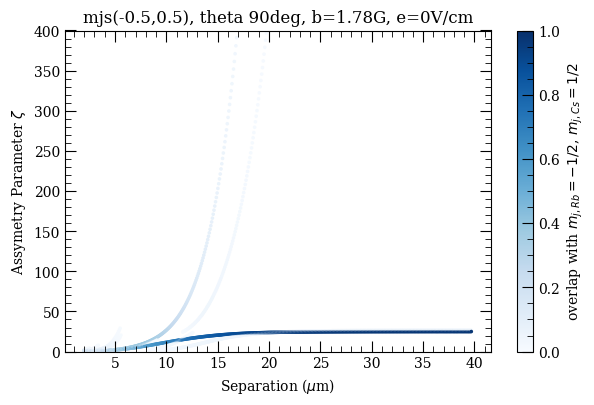

[np.float64(-1.5379811622006527), np.float64(1.8347997345644864), np.float64(-1.541227966286404), np.float64(1.836493521635467), np.float64(0.361359091883385), np.float64(0.36307646159331736), np.float64(-1.1085074515076514), np.float64(-1.1063552853657976), np.float64(1.0495739555637316), np.float64(1.0521149212300986), np.float64(-1.063936929452907), np.float64(-1.0797754613788881), np.float64(-1.159466614186652), np.float64(-1.1603843203996207), np.float64(1.8444554229818342), np.float64(1.846477151617754), np.float64(-1.540220912284883), np.float64(-1.5437253974416691), np.float64(0.35053623975438364), np.float64(0.35230252213624863), np.float64(-1.155711160281094), np.float64(1.0290879773510717), np.float64(1.0322205367721362), np.float64(-1.2470990591902502), np.float64(-2.7983872619589456), np.float64(-2.802995156467715), np.float64(1.8676665967560313), np.float64(-1.2353227308275465), np.float64(1.8700587255530032), np.float64(-1.1589200686215415), np.float64(-1.169076382843426

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


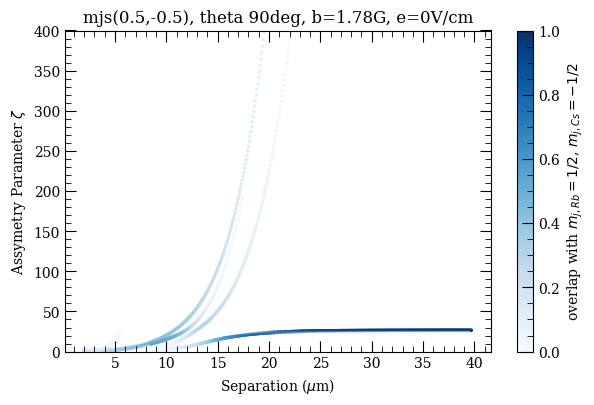

[np.float64(-1.5415978333950726), np.float64(1.8369342471892427), np.float64(-1.5383502501344906), np.float64(1.8352400536397004), np.float64(0.36316359344143634), np.float64(0.3614458115935315), np.float64(-1.106620790819572), np.float64(-1.1087734734427546), np.float64(1.0523674099679199), np.float64(1.0498258345153013), np.float64(-1.0640098204426136), np.float64(-1.1585138001270423), np.float64(-1.079849437476401), np.float64(-1.1595460499752783), np.float64(1.8466036549313678), np.float64(-1.160463819060878), np.float64(1.8445817877855448), np.float64(-1.54383115904176), np.float64(-1.155790338781206), np.float64(-1.5403264337904865), np.float64(0.3523266586041197), np.float64(0.35056025521313533), np.float64(1.032291254851787), np.float64(1.0291584808171022), np.float64(-1.2359756425323634), np.float64(-2.8044766384323325), np.float64(-1.247758195100642), np.float64(-2.7998663084885274), np.float64(1.8710471176550336), np.float64(1.8686537245334836), np.float64(-1.159532598820223

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


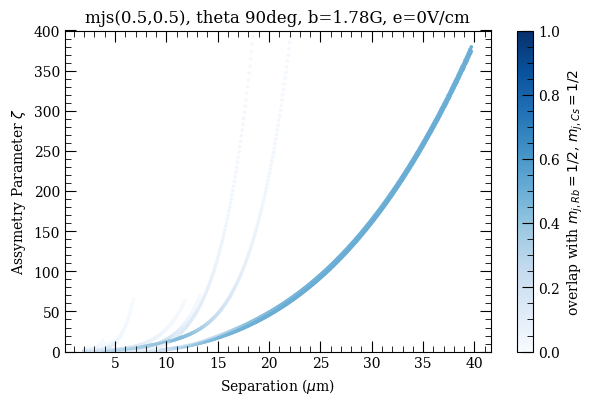

[np.float64(1.8328708306316883), np.float64(0.35960787745174455), np.float64(-1.553181310345424), np.float64(-1.5428254643833306), np.float64(1.0488563211188324), np.float64(1.839872797635274), np.float64(0.36643936733236737), np.float64(-1.1089523317426517), np.float64(1.0578396134161396), np.float64(-1.1618194532772836), np.float64(1.8424268453079935), np.float64(-1.167150512805537), np.float64(0.348360156038101), np.float64(-1.0819805745564852), np.float64(-1.1603600017192572), np.float64(-1.5600311513082552), np.float64(-1.1622982883789605), np.float64(-1.1362131361638215), np.float64(1.8505158695201116), np.float64(-1.5455608932144211), np.float64(1.0286191802339606), np.float64(0.35560501440264536), np.float64(1.039353120836885), np.float64(1.8655049546191935), np.float64(0.3427067108776165), np.float64(-2.8187253094503024), np.float64(-1.249394464886715), np.float64(-1.5432559750983805), np.float64(-1.5913228116500826), np.float64(-2.804517456042364), np.float64(1.87482749822815

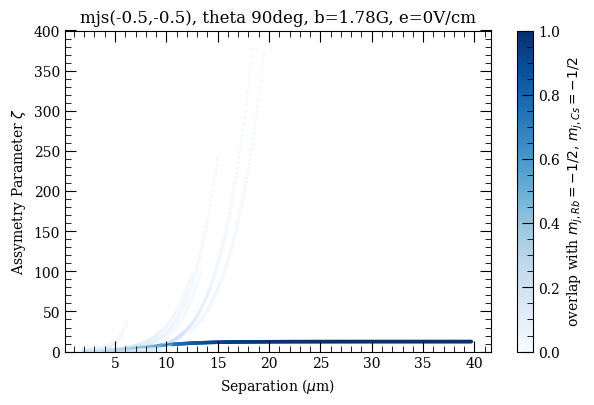

[np.float64(-0.4826796926162037), np.float64(1.8455944829610844), np.float64(0.37128411214239193), np.float64(-1.5391197525250724), np.float64(-1.5494854974733971), np.float64(1.0630950143446296), np.float64(1.8385807099398317), np.float64(0.364440290107271), np.float64(-1.1088048018951868), np.float64(1.0541000889900616), np.float64(1.856656214861871), np.float64(-1.0774312260017378), np.float64(-1.1577931019461443), np.float64(0.3609370930575939), np.float64(-1.1573137556702948), np.float64(-1.5412608232046634), np.float64(-1.1316928312563292), np.float64(-1.16265019303248), np.float64(-1.555742061644189), np.float64(1.848554592618407), np.float64(1.0450537188117281), np.float64(0.3536787566586717), np.float64(1.0343073613375668), np.float64(1.8826960563197292), np.float64(-1.5393065583514798), np.float64(-2.8020109160462208), np.float64(0.3565924630248824), np.float64(-1.2451086976975934), np.float64(-2.8162390350980835), np.float64(-1.1669484921255968), np.float64(-1.58742914416501

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


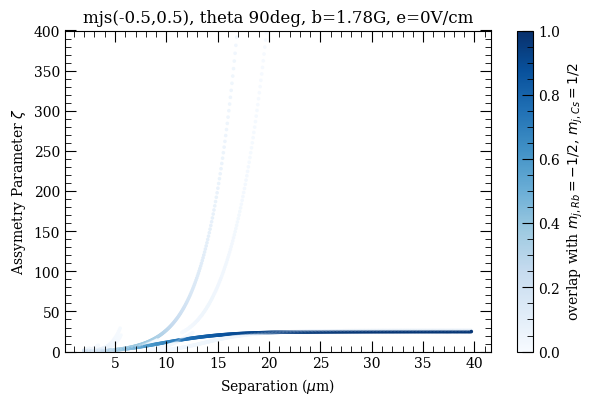

[np.float64(-1.5379809139381266), np.float64(1.834799452254447), np.float64(-1.5412277475298302), np.float64(1.8364932523024808), np.float64(0.36135903685814535), np.float64(0.36307643630972314), np.float64(-1.1085073187408774), np.float64(-1.1063551074799636), np.float64(1.0495737964670406), np.float64(1.0521147769656183), np.float64(-1.0639365945047345), np.float64(-1.0797755330581245), np.float64(-1.1594663080513832), np.float64(-1.1603860494070195), np.float64(1.8444547349552447), np.float64(1.8464764784017942), np.float64(-1.5402203224857234), np.float64(-1.5437248481276917), np.float64(0.35053611578937977), np.float64(0.3523024225143733), np.float64(-1.155710464456818), np.float64(1.0290875969479802), np.float64(1.0322201729711753), np.float64(-1.2470998366577477), np.float64(-2.7983873434496944), np.float64(-2.802995307419195), np.float64(1.867666670666737), np.float64(-1.235322091831817), np.float64(1.8700588174232042), np.float64(-1.1589206031412067), np.float64(-1.16907673992

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


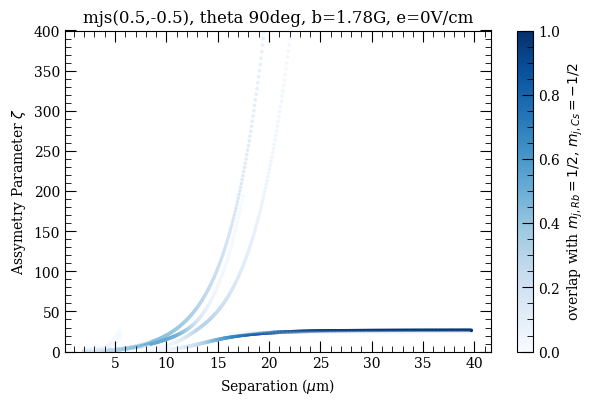

[np.float64(-1.5415980822087894), np.float64(1.8369345350007014), np.float64(-1.538350468450055), np.float64(1.835240327957077), np.float64(0.36316367831253155), np.float64(0.3614458661947689), np.float64(-1.1066209485694458), np.float64(-1.1087736769755172), np.float64(1.0523675848901968), np.float64(1.0498259938308512), np.float64(-1.0640102718165165), np.float64(-1.1585123068275878), np.float64(-1.079850307211974), np.float64(-1.159546600769126), np.float64(1.8466043463818034), np.float64(-1.160466405816594), np.float64(1.8445824629300853), np.float64(-1.5438317506419286), np.float64(-1.1557904970834416), np.float64(-1.540326982312539), np.float64(0.3523268193586582), np.float64(0.35056039031741765), np.float64(1.0322916539296312), np.float64(1.0291588609764222), np.float64(-1.2359748922887597), np.float64(-2.8044765378040397), np.float64(-1.247758861011482), np.float64(-2.7998661387765047), np.float64(1.8710470416754825), np.float64(1.8686536307997175), np.float64(-1.15953302957176

C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\2521273050.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(abs(val_big * val_third))


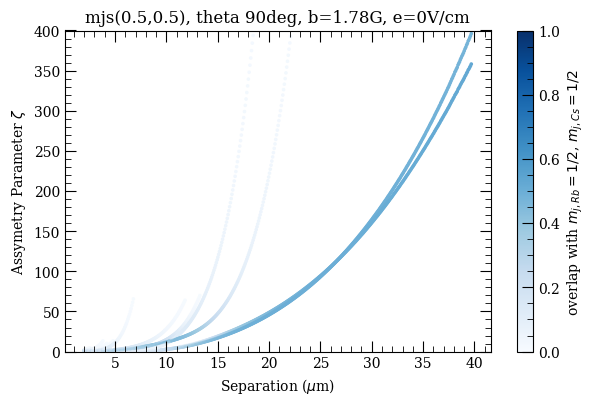

[np.float64(1.8328618345605152), np.float64(0.35959857545965873), np.float64(-1.5531883650195561), np.float64(-1.5428287880212455), np.float64(1.0488480046885977), np.float64(1.8398714341623346), np.float64(0.3664383252016227), np.float64(-1.1089533385323536), np.float64(1.057837577774685), np.float64(-1.1618254921837377), np.float64(1.842416696597725), np.float64(-1.167159042560418), np.float64(0.348349580871586), np.float64(-1.0819861785579445), np.float64(-1.1603620541650004), np.float64(-1.5600382504680328), np.float64(-1.1623045791356867), np.float64(-1.136218428559731), np.float64(1.8505139359047098), np.float64(-1.545564846304941), np.float64(1.0286099689328012), np.float64(0.3556039905473873), np.float64(1.0393505126821583), np.float64(1.865494734227728), np.float64(0.34269494246737403), np.float64(-2.8187346642851914), np.float64(-1.2494012570544606), np.float64(-1.543262638296612), np.float64(-1.5913301854387925), np.float64(-2.804522818190304), np.float64(1.8748261701212774)

In [32]:
# assymetry parameter
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'
if not os.path.exists(datapath_asym + 'inter'):
    os.makedirs(datapath_asym + 'inter')
if not os.path.exists(datapath_asym + 'intra Rb'):
    os.makedirs(datapath_asym + 'intra Rb')
if not os.path.exists(datapath_asym + 'intra Cs'):
    os.makedirs(datapath_asym + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\assymetry\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]
print(ket1, ket2)
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            corrected_intra_Rb = pd.read_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {np.round(b,3)}G.csv')
            corrected_intra_Cs = pd.read_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(400)
            offset=defect/2

            plt.ylim(0, energy_lim)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            
            big_lookup = dict(zip(corrected_intra_Rb['r'], corrected_intra_Rb['energy']))
            third_lookup = dict(zip(corrected_intra_Cs['r'], corrected_intra_Cs['energy']))

            # 2. Initialize your results (will be same length as the loop source)
            assym = {
            'energy': [],
            'r': [],
            'overlap': []
            }

            # 3. Iterate through EVERY element of the PRIMARY dataset
            for i, r in enumerate(corrected_inter['r']):
                current_energy = corrected_inter['energy'][i]
                # print(i)
                # Use .get(theta, 0) to "safely" grab the value. 
                # If the theta doesn't exist in that specific set, it defaults to 0.
                val_big = big_lookup.get(r, 0)
                val_third = third_lookup.get(r, 0)

                # 4. Perform your manipulation (e.g., subtracting both from the original)
                final_calc = current_energy/np.sqrt(abs(val_big * val_third))

                # 5. Append to keep the output arrays aligned with the input
                assym['energy'].append(final_calc)
                assym['r'].append(r)
                assym['overlap'].append(corrected_inter['overlap'][i])
                    
                    
                    

            # print(energies['energy']-overlapped_inter['energy'])

            scat = plt.scatter(
                assym['r'],
                abs(np.array(assym['energy'])),
                c=assym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )
            plt.ylabel(r'Assymetry Parameter $\zeta$')
            pd.DataFrame(assym).to_csv(datapath_asym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'theta {theta}deg, b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()
            print(assym['energy'])


C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\1331725944.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = plt.legend()


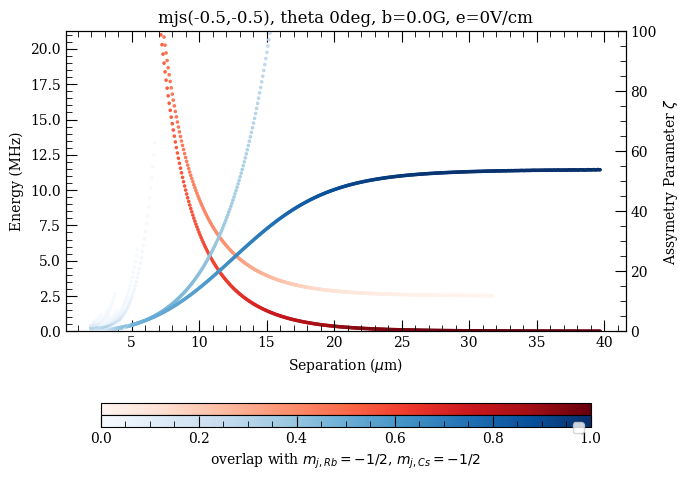

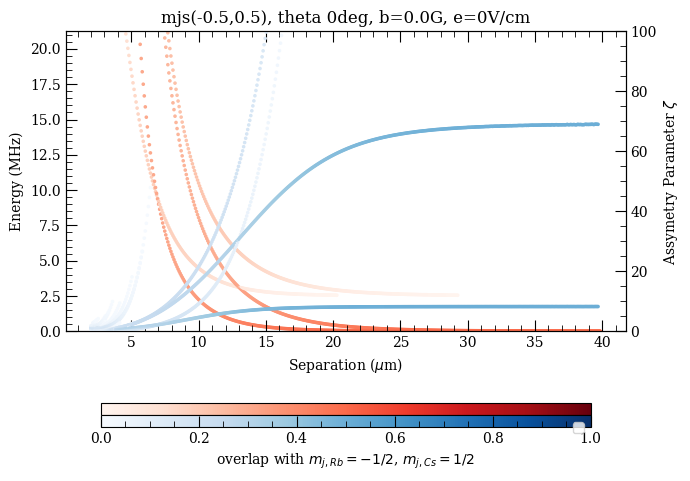

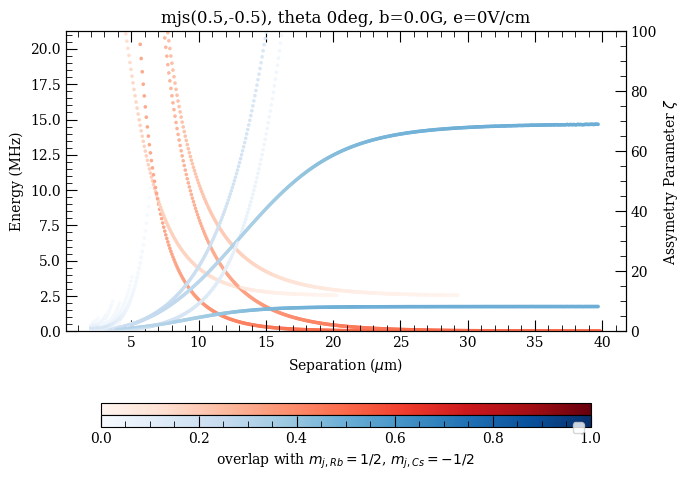

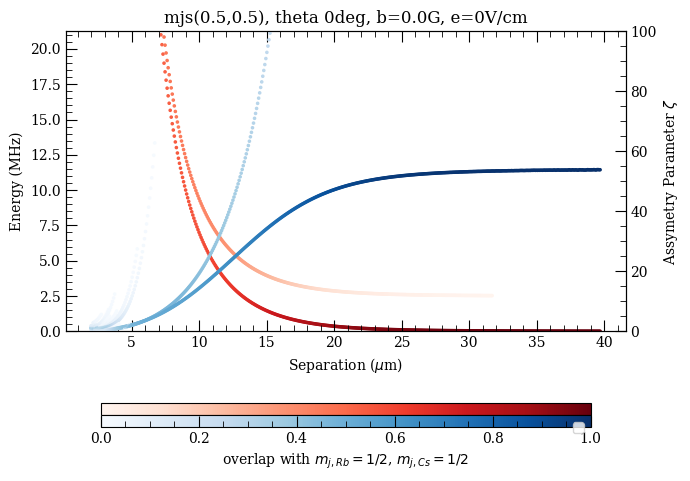

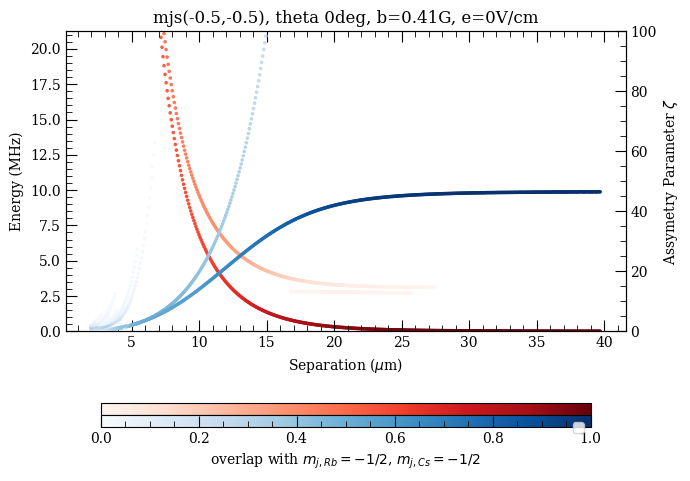

...

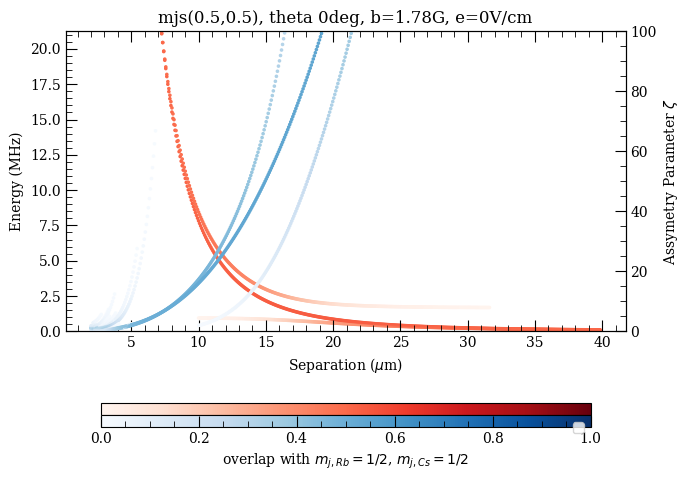

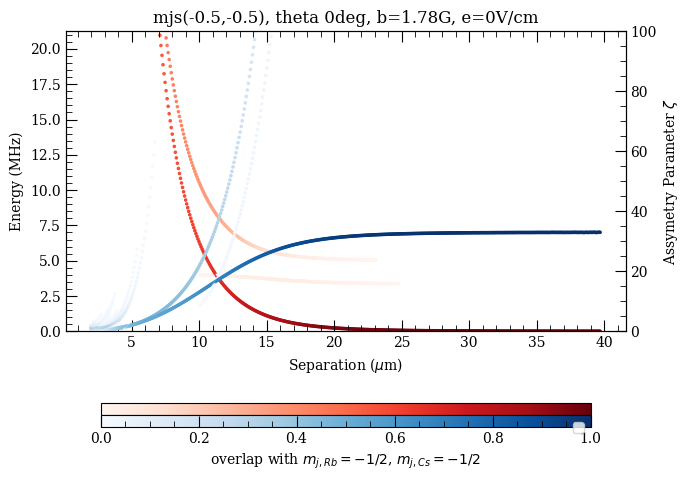

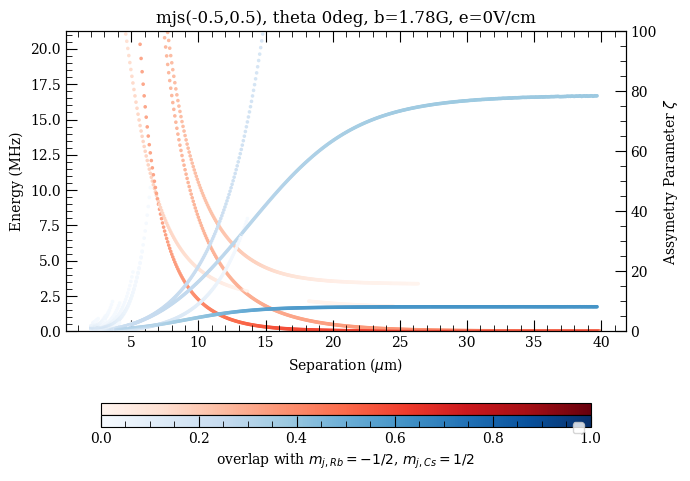

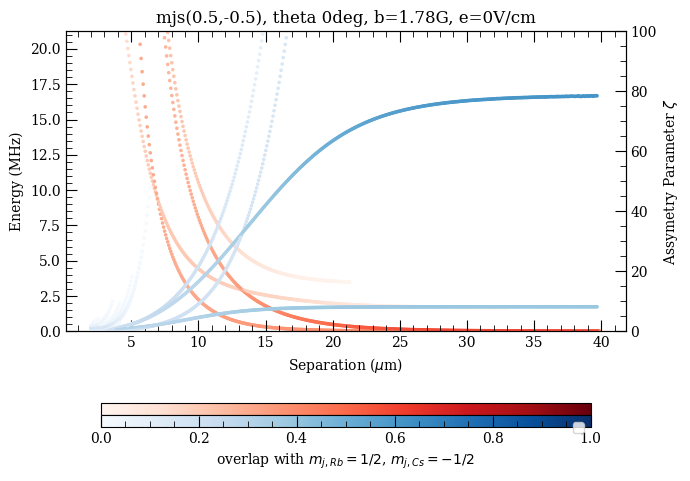

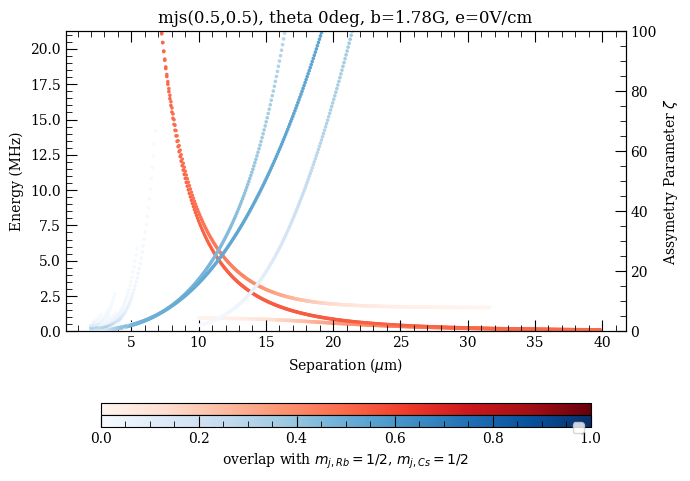

In [33]:
# both plotted together
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'

import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\dual plots\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
theta=0
# system_atom = system_atom_dict[efield]
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            assym = pd.read_csv(datapath_asym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(1, 1, figsize=(7, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            ax.set_title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(20)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(0, max_energy)

            # print(energies['energy']-overlapped_inter['energy'])

            ax.set_ylabel(f"Energy ({energy_unit})")  # Label for the first y-axis
            ax1 = ax.twinx()  # Create a second y-axis
            ax1.set_ylabel(r'Assymetry Parameter $\zeta$')  # Label
            scat_assym = ax1.scatter(
                assym['r'],
                abs(np.array(assym['energy'])),
                c=assym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                label = r'$\zeta$',
                cmap = 'Blues'
            )
            
            scat_energy = ax.scatter(
                corrected_inter['r'],
                abs(np.array(corrected_inter['energy'])),
                c=corrected_inter['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds',
                label = r'$\Delta E$'
            )
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            
            plt.subplots_adjust(left=0.1, right=0.9, top=1, bottom=.25, wspace=0.4, hspace=.4)

            cax1 = fig.add_axes([0.15, 0.04, 0.7, 0.03]) 
            cax2 = fig.add_axes([0.15, 0.01, 0.7, 0.03])

            fig.colorbar(scat_energy, cax=cax1, orientation='horizontal', ticks=[])
            fig.colorbar(scat_assym, cax=cax2, orientation='horizontal', label=fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            # ax.set_ylim(0, max_energy)
            # ax.set_yscale('log')
            ax1.set_ylim(0, 100)
            # pd.DataFrame(assym).to_csv(datapath_assym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            # plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$', location='bottom')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()


C:\Users\tommy\AppData\Local\Temp\ipykernel_6484\242199924.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = plt.legend()


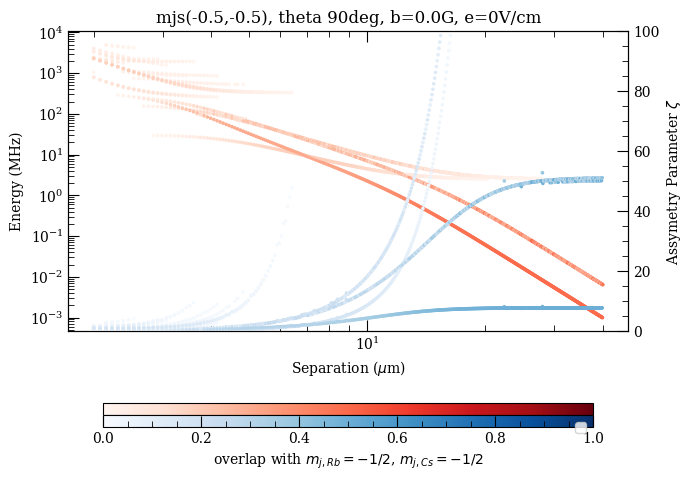

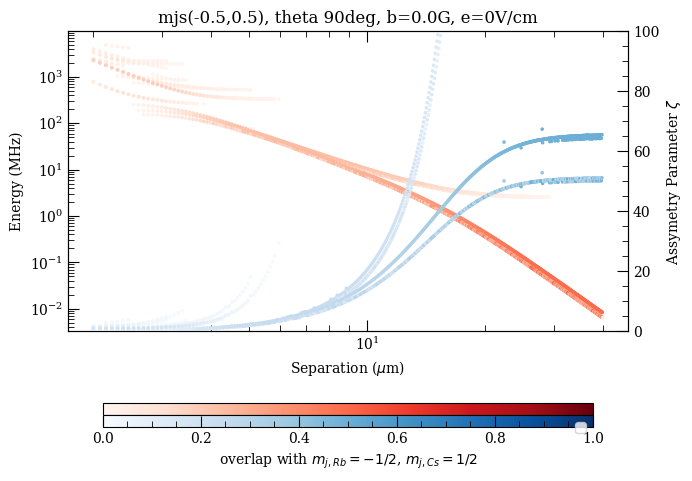

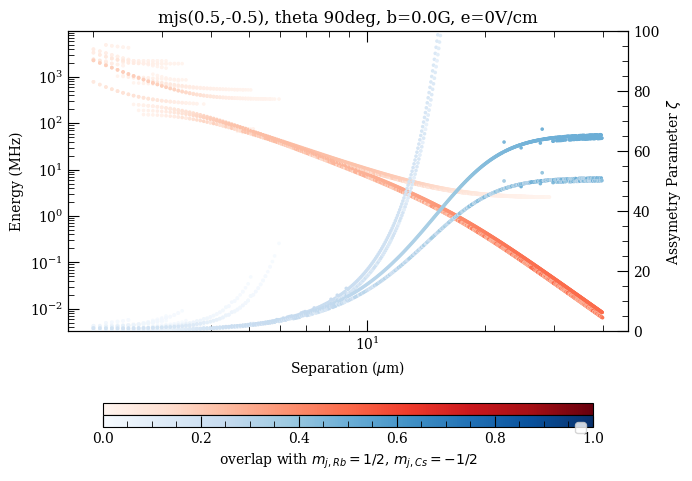

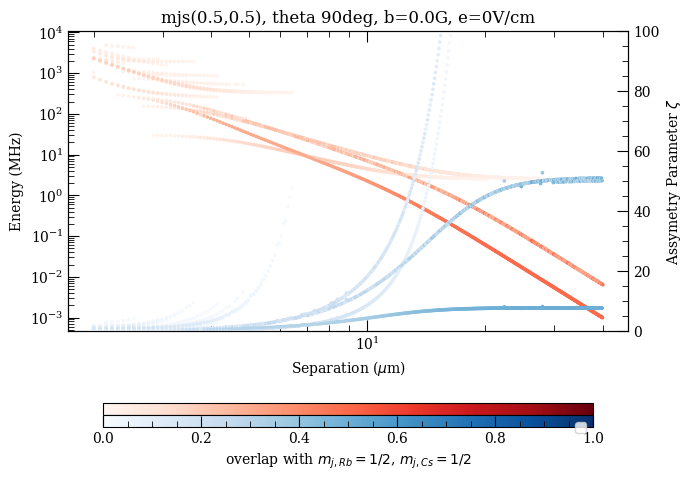

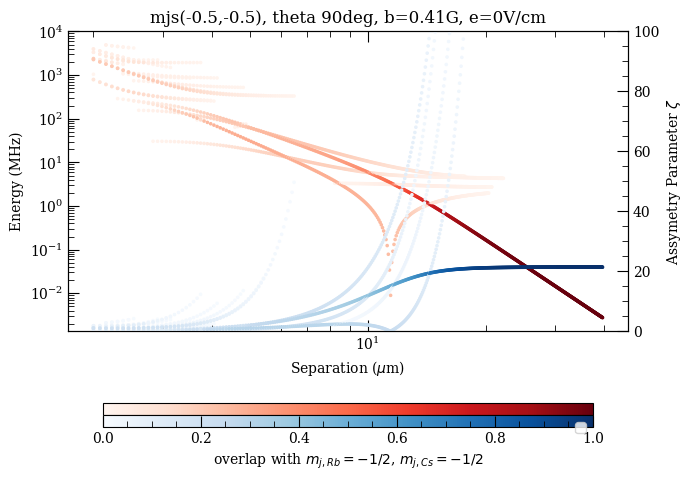

...

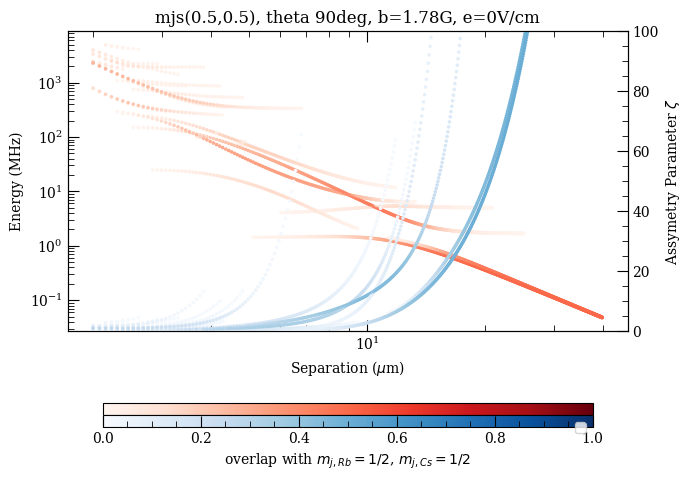

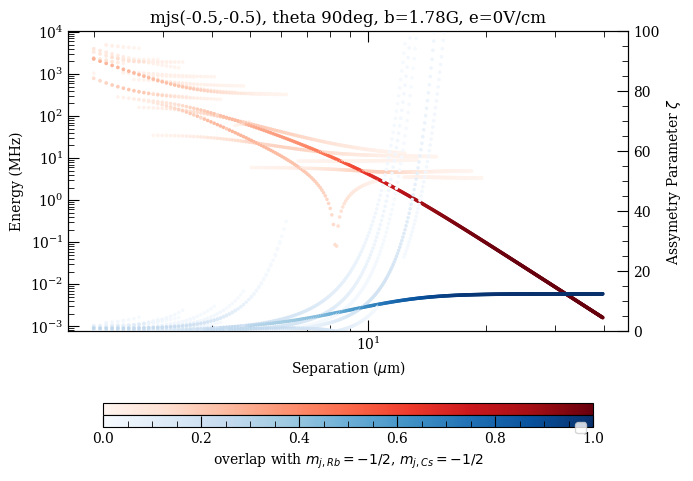

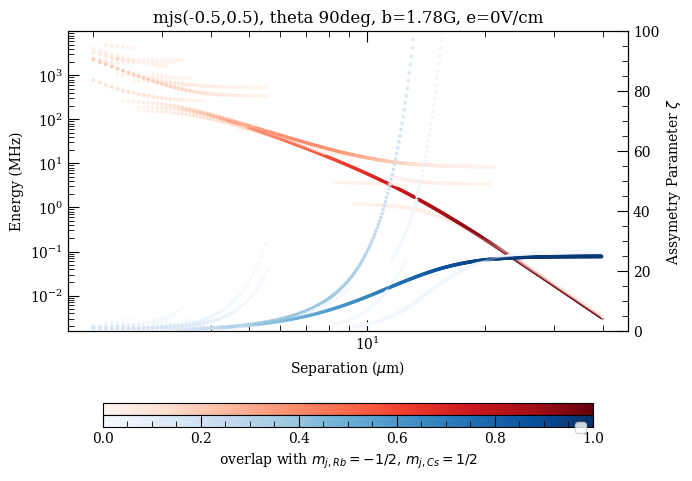

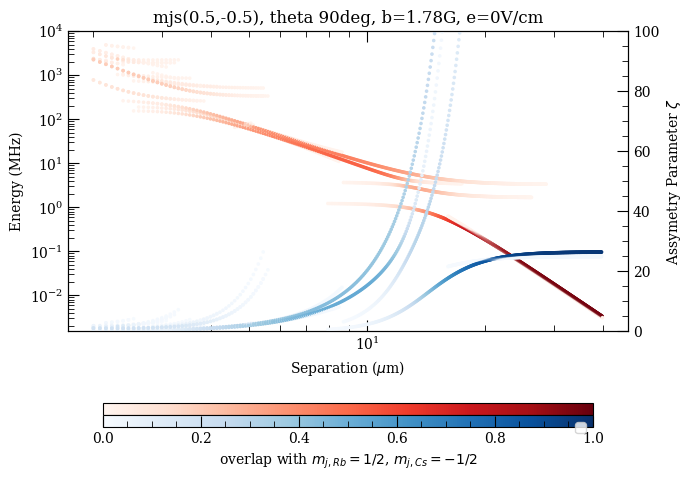

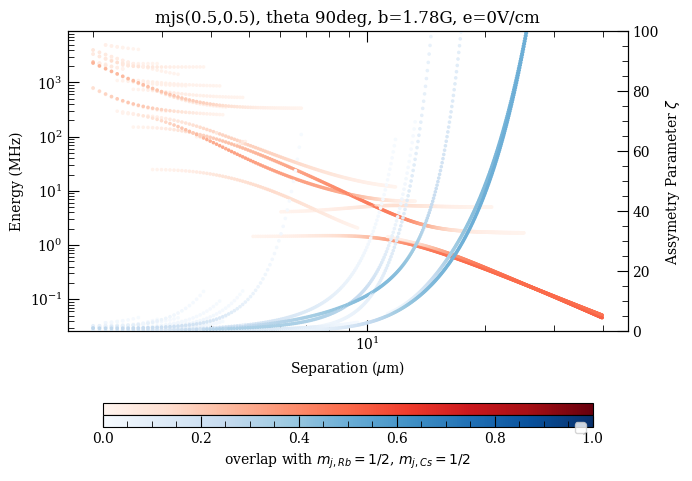

In [30]:
# both plotted together log scale
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'

import os
figpath_log = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\dual plots\\log scale\\'
if not os.path.exists(figpath_log):
    os.makedirs(figpath_log)
# ax.set_ylim(-0.01, 0.01)
theta=90
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# theta=0
# system_atom = system_atom_dict[efield]
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            assym = pd.read_csv(datapath_asym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,3)}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(1, 1, figsize=(7, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            ax.set_title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(20)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(0, max_energy)

            # print(energies['energy']-overlapped_inter['energy'])

            ax.set_ylabel(f"Energy ({energy_unit})")  # Label for the first y-axis
            ax1 = ax.twinx()  # Create a second y-axis
            ax1.set_ylabel(r'Assymetry Parameter $\zeta$')  # Label
            scat_assym = ax1.scatter(
                assym['r'],
                abs(np.array(assym['energy'])),
                c=assym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                label = r'$\zeta$',
                cmap = 'Blues'
            )
            # ax1.set_yscale('log')
            
            scat_energy = ax.scatter(
                corrected_inter['r'],
                abs(np.array(corrected_inter['energy'])),
                c=corrected_inter['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds',
                label = r'$\Delta E$'
            )
            ax.set_yscale('log')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            
            plt.subplots_adjust(left=0.1, right=0.9, top=1, bottom=.25, wspace=0.4, hspace=.4)

            cax1 = fig.add_axes([0.15, 0.04, 0.7, 0.03]) 
            cax2 = fig.add_axes([0.15, 0.01, 0.7, 0.03])

            fig.colorbar(scat_energy, cax=cax1, orientation='horizontal', ticks=[])
            fig.colorbar(scat_assym, cax=cax2, orientation='horizontal', label=fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            # ax.set_ylim(0, max_energy)
            ax1.set_ylim(0, 100)
            ax.set_xscale('log')
            # pd.DataFrame(assym).to_csv(datapath_assym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            # plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$', location='bottom')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath_log + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()


NameError: name 'angle' is not defined

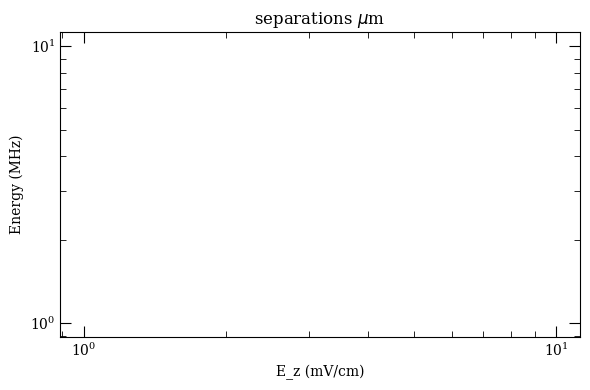

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\separations\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

for mj1 in mj1_0s:
    for mj2 in mj2_0s:

        ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


        # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
        fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel("E_z (mV/cm)")
        ax.set_ylabel(f"Energy ({energy_unit})")
        ax.set_title(fr'separations $\mu$m')
        plt.tight_layout()
        plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')
        energy_lim = abs(defect + defect*2)
        offset=defect/2
        min_energy = -energy_lim+offset
        max_energy = energy_lim+offset
        # plt.ylim(min_energy, max_energy)
        # plt.xlim(2, 2.7)
        plt.ylabel(f"Energy [{energy_unit}]")
        plt.xlabel("Magnetic Field [G]")
        # ax.plot(e_fields_sub, energies)

        for x, es in zip(rs, energies):
            plt.plot([x] * len(es), abs(es), c='.9', ls="None", marker=".", ms=1, zorder=-1)
        min_overlap = 0.000
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
        fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {mj1}, $m_j$ = {mj2}")
        # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
        fig.savefig(figpath + f'level pairstate deg{angle} b{b}G e{e}Vcm mjs{mj1},{mj2}.png')


{'mjs0-0.5-0.5': [], 'mjs0-0.50.5': [], 'mjs00.5-0.5': [], 'mjs00.50.5': []}


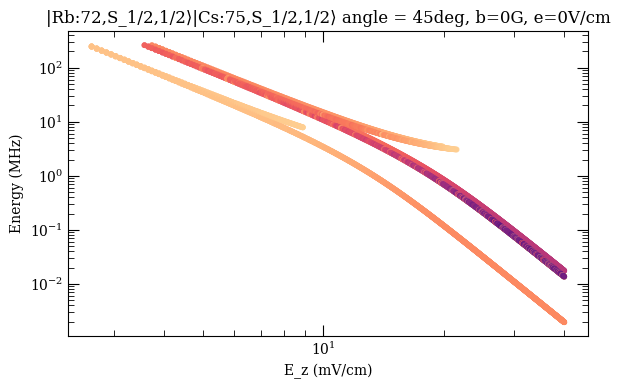

In [10]:
min_overlap = 0.1
energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
print(energies_dict_0)
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_0, ket2_0]) for system in system_pairs]

        energies1=[]
        ds=[]
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
                ds = np.append(ds, [x] * len(es[inds]))
        energies_dict_0[f'rs{mj1_0}{mj2_0}'] = ds
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies1

[ 2.64128257  2.64128257  2.71943888 ... 39.92184369 40.
 40.        ]
182 182
[[445056.6512226]]
[117.84927326]


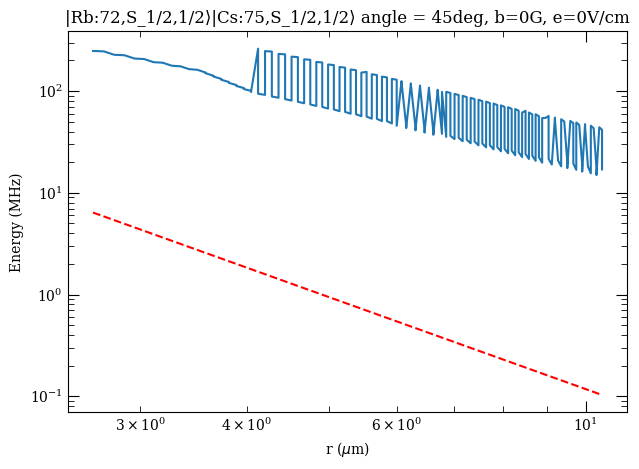

In [18]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c):
    return c/(r)**3 
rmax=10.5
mj1_0, mj2_0 = -1/2, -1/2
ds = energies_dict_0[f'rs{mj1_0}{mj2_0}']
print(ds)
ds = ds[np.argwhere(ds<rmax)].flatten()[::2]

energy = energies_dict_0[f'mjs0{mj1_0}{mj2_0}']
energy = energy[np.argwhere(ds<rmax)].flatten()
print(len(ds), len(energy))
popt, pcov = scipy.optimize.curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)